## 1. Imports & chemins

In [1]:
%matplotlib inline

import os, sys, warnings
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import scipy.io
from scipy.ndimage import binary_dilation, label as scipy_label

import SimpleITK as sitk
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import seaborn as sns

warnings.filterwarnings('ignore')

PROJECT_ROOT = "/Users/arslenebouhadjera/Stage_Arslène_2026/Documents/StageNoé2025/pipeline-vessel-enhancement-master"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from core.utils.helpers import normalize_data
from core.utils.searcher import GridSearcher
from core.processing.derivator import Derivator
from core.processing.enhancer import Enhancer
from core.processing.segmenter import Segmenter
from core.processing.processor import Processor
from core.config.experiment import (
    ProcessingConfig, HessianConfig, EnhancementConfig,
    SegmentationConfig, MethodsConfig,
)
from core.experiments.metrics import (
    detailed_metrics, connected_components_metrics, bifurcation_detection_rate
)

print("Imports OK ✓")

Imports OK ✓


In [2]:
PROJECT_ROOT   = Path("/Users/arslenebouhadjera/Stage_Arslène_2026/Documents/StageNoé2025/pipeline-vessel-enhancement-master")
IMAGES_DIR     = PROJECT_ROOT / "data" / "vascusynth" / "images"
LABELS_DIR     = PROJECT_ROOT / "data" / "vascusynth" / "labels"
VOLUME_SHAPE   = (101, 101, 101)
DILATION_RADIUS = 3
FORCE_RECONVERT = False

METHODS = ['default', 'gaussian', 'farid', 'cubic', 'trigonometric', 'catmull', 'bspline', 'bezier', 'scharr']

METHOD_COLORS = {
    'default'       : '#4C72B0',
    'gaussian'      : '#DD8452',
    'farid'         : '#55A868',
    'cubic'         : '#C44E52',
    'trigonometric' : '#8172B2',
    'catmull'       : '#937860',
    'bspline'       : '#DA8BC3',
    'bezier'        : '#CCB974',
    'scharr'        : '#64B5CD',
}

assert IMAGES_DIR.exists() and LABELS_DIR.exists()
print(f"Répertoires OK ✓  — {len(METHODS)} opérateurs")

Répertoires OK ✓  — 9 opérateurs


## 2. Conversion labels `.mat` → volumes 3D

In [3]:
def _draw_segment(c1, c2, volume, shape):
    c1, c2 = np.array(c1, float), np.array(c2, float)
    n_steps = int(np.ceil(np.linalg.norm(c2 - c1))) + 1
    for t in np.linspace(0, 1, max(n_steps, 2)):
        p = np.round(c1 + t * (c2 - c1)).astype(int)
        if all(0 <= p[i] < shape[i] for i in range(3)):
            volume[p[0], p[1], p[2]] = 1


def mat_to_volume(path, shape=VOLUME_SHAPE, dilation=DILATION_RADIUS):
    mat   = scipy.io.loadmat(str(path))
    node  = mat['node'][0]
    vol   = np.zeros(shape, dtype=np.uint8)
    coords = {}
    for idx, n in enumerate(node):
        coord = np.array(n['coord']).flatten()
        if coord.size != 3: continue
        coords[idx] = coord
        xi, yi, zi = int(round(coord[0])), int(round(coord[1])), int(round(coord[2]))
        if all(0 <= v < shape[i] for i, v in enumerate([xi, yi, zi])):
            vol[xi, yi, zi] = 1
    for idx, n in enumerate(node):
        par = np.array(n['parent']).flatten()
        if par.size == 0: continue
        pi = int(par[0]) - 1
        if pi >= 0 and pi in coords and idx in coords:
            _draw_segment(coords[pi], coords[idx], vol, shape)
    if dilation > 0:
        vol = binary_dilation(vol, iterations=dilation).astype(np.uint8)
    return vol


mat_files = sorted(LABELS_DIR.glob("*.mat"))
print(f"{len(mat_files)} fichier(s) .mat")
for mp in mat_files:
    np_ = mp.with_suffix(".npy")
    if np_.exists() and not FORCE_RECONVERT:
        print(f"  [cache] {np_.name}  voxels={np.load(np_).sum()}")
    else:
        v = mat_to_volume(mp)
        np.save(np_, v)
        print(f"  [conv]  {mp.name}  voxels={v.sum()}")
print("Conversion OK ✓")

12 fichier(s) .mat
  [cache] treeStructure_1.npy  voxels=1465
  [cache] treeStructure_10.npy  voxels=26223
  [cache] treeStructure_11.npy  voxels=29443
  [cache] treeStructure_12.npy  voxels=32817
  [cache] treeStructure_2.npy  voxels=6789
  [cache] treeStructure_3.npy  voxels=7959
  [cache] treeStructure_4.npy  voxels=15754
  [cache] treeStructure_5.npy  voxels=14950
  [cache] treeStructure_6.npy  voxels=19486
  [cache] treeStructure_7.npy  voxels=21497
  [cache] treeStructure_8.npy  voxels=24960
  [cache] treeStructure_9.npy  voxels=25116
Conversion OK ✓


## 3. Helpers : chargement, contraste, pipeline

In [4]:
def load_mhd(images_dir, idx):
    path = Path(images_dir) / f"testVascuSynth{idx}_101_101_101_uchar.mhd"
    arr  = sitk.GetArrayFromImage(sitk.ReadImage(str(path))).astype(np.float32)
    arr  = np.transpose(arr, (2, 1, 0))
    arr  = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    return arr


def load_label(labels_dir, idx):
    path = Path(labels_dir) / f"treeStructure_{idx}.npy"
    vol  = np.load(path).astype(np.uint8)
    if vol.sum() < 100:
        raise RuntimeError(f"Label trop vide ({vol.sum()} voxels)")
    return vol


def detect_contrast(image, label):
    vm = label.astype(bool)
    mu_v = float(image[vm].mean())
    mu_b = float(image[~vm].mean())
    return mu_v < mu_b, mu_v, mu_b


def make_enh_cfg(black_ridges):
    return EnhancementConfig(
        scales=[1.4, 1.87, 2.33, 2.8], alpha=0.5, beta=0.5, gamma=0.5,
        black_ridges=black_ridges, skimage=False,
    )


def run_pipeline(idx, processing_cfg, hessian_cfg, segmentation_cfg, method_name, benchmark_config=None):
    """Exécute le pipeline complet et retourne (enhanced, segmented, threshold, label, black_ridges, hessian_time)."""
    img = load_mhd(IMAGES_DIR, idx)
    lbl = load_label(LABELS_DIR, idx)
    br, _, _ = detect_contrast(img, lbl)
    enh_cfg  = make_enh_cfg(br)
    methods  = MethodsConfig(derivator=method_name, enhancer='frangi', segmenter='thresholding')
    proc     = Processor(processing_cfg)
    
    enh, seg, thr, hessian_time = proc.process_data(
        data=img, 
        hessian_config=hessian_cfg, 
        enhancement_config=enh_cfg,
        segmentation_config=segmentation_cfg, 
        methods=methods,
        ground_truth=lbl.astype(np.float32),
        benchmark_config=benchmark_config,  
    )
    
    return enh, seg, float(thr), lbl, br, hessian_time


print("Helpers définis ✓")

Helpers définis ✓


## 4. Configuration globale

In [5]:
processing_cfg = ProcessingConfig(
    use_gpu=False, normalize=False, parallelize=False, show_progress=False,
    chunk_size=(64, 64, 64), overlap_size=10,
)
hessian_cfg    = HessianConfig(mode='reflect', cval=0.0)
seg_cfg        = SegmentationConfig(threshold=None)   # seuil F1-optimal

print("Configuration globale ✓")

Configuration globale ✓


## 5. Benchmark — collecte de toutes les métriques

Pour chaque opérateur × 12 volumes, on collecte :
- **Métriques classiques** : Dice, MCC, sensibilité, spécificité, précision, accuracy
- **AUC** : ROC-AUC, PR-AUC
- **Topologique** : clDice
- **Composantes connexes** : fragmentation, recall, overlap squelette…
- **Bifurcations** : BDR, précision bifurcations
- **Temps Hessien**


In [ ]:
# ─── Collecte des données brutes ───────────────────────────────────────────
RAW_METRICS    = {m: [] for m in METHODS}
SAVED_BINARY   = {m: [] for m in METHODS}
SAVED_ENHANCED = {m: [] for m in METHODS}
SAVED_GT       = {m: [] for m in METHODS}
HESSIAN_TIMES  = {m: [] for m in METHODS}
BIF_METRICS    = {m: [] for m in METHODS}

print(f"{'BENCHMARK':^72}")
print(f"{'9 opérateurs × 12 volumes VascuSynth':^72}")
print(f"{'Pipeline : Hessien → Frangi → seuillage F1-optimal':^72}")
print("─" * 72)

for method in METHODS:
    print(f"\n▶  {method.upper():<16}", end="", flush=True)
    for idx in range(1, 13):
        try:
            enh, seg, thr, lbl, br, hessian_time = run_pipeline(
                idx, processing_cfg, hessian_cfg, seg_cfg, method
            )
            m = detailed_metrics(
                y_pred=enh,
                y_true=lbl.astype(np.float32),
                threshold=thr,
            )
            # Bifurcations
            bif = bifurcation_detection_rate(
                v_pred=seg.astype(bool),
                v_gt=lbl.astype(bool),
            )
            m.update(bif)
            m['hessian_time_seconds'] = hessian_time

            RAW_METRICS[method].append(m)
            SAVED_BINARY[method].append(seg.astype(bool))
            SAVED_ENHANCED[method].append(enh)
            SAVED_GT[method].append(lbl.astype(bool))
            HESSIAN_TIMES[method].append(hessian_time)
            print(".", end="", flush=True)
        except Exception as e:
            import traceback
            RAW_METRICS[method].append(None)
            SAVED_BINARY[method].append(None)
            SAVED_ENHANCED[method].append(None)
            SAVED_GT[method].append(None)
            HESSIAN_TIMES[method].append(None)
            print("E", end="", flush=True)
            print(f"\n  x {method.upper()} vol {idx}: {type(e).__name__}: {e}")
            traceback.print_exc()
    print("  ✓")

print("\nBenchmark terminé ✓")

                               BENCHMARK                                
                  9 opérateurs × 12 volumes VascuSynth                  
           Pipeline : Hessien → Frangi → seuillage F1-optimal           
────────────────────────────────────────────────────────────────────────

▶  DEFAULT         ............  ✓

▶  GAUSSIAN        ............  ✓

▶  FARID           ............  ✓

▶  CUBIC           ............  ✓

▶  TRIGONOMETRIC   ............  ✓

▶  CATMULL         ............  ✓

▶  BSPLINE         ............  ✓

▶  BEZIER          ............  ✓

▶  SCHARR          ............  ✓

Benchmark terminé ✓


## 6. Tableau synthétique — 9 opérateurs × toutes métriques

Toutes les métriques sont présentées sous forme **moyenne ± écart-type** sur les 12 volumes VascuSynth.


In [7]:
# ─── Clés à agréger ────────────────────────────────────────────────────────
FLOAT_KEYS = [
    # Confusion matrix
    'tp', 'fp', 'fn', 'tn', 'gt_vessels', 'pred_vessels',
    # Métriques classiques
    'dice', 'mcc', 'sensitivity', 'specificity', 'precision', 'accuracy',
    # AUC
    'roc', 'pr',
    # Topologique
    'cldice',
    # Composantes connexes — GT
    'n_components_gt', 'gt_small_components', 'gt_medium_components', 'gt_large_components',
    'largest_component_gt',
    # Composantes connexes — Prédiction
    'n_components_pred', 'pred_small_components', 'pred_medium_components', 'pred_large_components',
    'largest_component_pred',
    # Ratios
    'components_ratio', 'largest_ratio', 'excess_components', 'missing_components',
    # Topologie additionnelle
    'largest_gt_recall', 'largest_component_overlap', 'fragmentation_ratio',
    'skeleton_component_connectivity',
    # Bifurcations
    'bifurcation_detection_rate', 'bifurcation_precision',
    'n_bifurcations_gt', 'n_bifurcations_pred', 'n_bifurcations_detected',
    # Temps
    'hessian_time_seconds',
    # Seuil
    'threshold',
]

rows = []
for method in METHODS:
    valid = [m for m in RAW_METRICS[method] if m is not None]
    if not valid:
        continue
    row = {'method': method}
    for k in FLOAT_KEYS:
        vals = [m[k] for m in valid if k in m and m[k] is not None]
        if vals:
            row[f'{k}_mean'] = float(np.mean(vals))
            row[f'{k}_std']  = float(np.std(vals))
        else:
            row[f'{k}_mean'] = np.nan
            row[f'{k}_std']  = np.nan
    rows.append(row)

df = pd.DataFrame(rows).set_index('method')
print(f"DataFrame construit : {df.shape[0]} opérateurs × {df.shape[1]} colonnes")

DataFrame construit : 9 opérateurs × 80 colonnes


In [8]:
# ─── Tableau principal : métriques demandées ────────────────────────────────
REQUESTED_METRICS = [
    'dice', 'mcc', 'roc', 'pr', 'cldice',
    'components_ratio', 'excess_components',
    'skeleton_component_connectivity', 'largest_gt_recall',
    'pred_small_components', 'pred_medium_components',
    'pred_large_components', 'largest_gt_recall', 'largest_component_overlap',
    'fragmentation_ratio', 'hessian_time_seconds',
    'bifurcation_detection_rate', 'bifurcation_precision',
    'n_bifurcations_gt', 'n_bifurcations_pred', 'n_bifurcations_detected',
]

# Construction du tableau mean ± std
table_rows = {}
for metric in REQUESTED_METRICS:
    mean_col = f'{metric}_mean'
    std_col  = f'{metric}_std'
    row = {}
    for method in METHODS:
        if method not in df.index:
            row[method] = 'N/A'
            continue
        if mean_col in df.columns:
            m_val = df.loc[method, mean_col]
            s_val = df.loc[method, std_col]
            if np.isnan(m_val):
                row[method] = 'N/A'
            elif metric in ('n_bifurcations_gt', 'n_bifurcations_pred', 'n_bifurcations_detected',
                            'excess_components', 'pred_small_components', 'pred_medium_components',
                            'pred_large_components', 'n_components_pred', 'n_components_gt'):
                row[method] = f"{m_val:.1f} ± {s_val:.1f}"
            elif metric == 'hessian_time_seconds':
                row[method] = f"{m_val:.3f} ± {s_val:.3f}"
            else:
                row[method] = f"{m_val:.4f} ± {s_val:.4f}"
        else:
            row[method] = 'N/A'
    table_rows[metric] = row

df_display = pd.DataFrame(table_rows, index=METHODS).T
df_display.index.name = 'metric'

# Noms lisibles
METRIC_LABELS = {
    'dice'                         : 'Dice',
    'mcc'                          : 'MCC',
    'roc'                          : 'ROC-AUC',
    'pr'                           : 'PR-AUC',
    'cldice'                       : 'clDice',
    'components_ratio'             : 'Components ratio',
    'excess_components'            : 'Excess components',
    'skeleton_component_connectivity': 'Skeleton connectivity',
    'largest_component_recall'     : 'Largest comp. recall',
    'gt_fragmentation'             : 'GT fragmentation ratio',
    'pred_small_components'        : 'Pred small CC (<10 vx)',
    'pred_medium_components'       : 'Pred medium CC (10–100 vx)',
    'pred_large_components'        : 'Pred large CC (≥100 vx)',
    'largest_gt_recall'            : 'Largest GT recall',
    'largest_component_overlap'    : 'Largest comp. overlap',
    'fragmentation_ratio'          : 'Fragmentation ratio',
    'hessian_time_seconds'         : 'Hessian time (s)',
    'bifurcation_detection_rate'   : 'Bifurcation det. rate',
    'bifurcation_precision'        : 'Bifurcation precision',
    'n_bifurcations_gt'            : 'N bifurcations GT',
    'n_bifurcations_pred'          : 'N bifurcations pred',
    'n_bifurcations_detected'      : 'N bifurcations detected',
}
df_display.index = [METRIC_LABELS.get(m, m) for m in df_display.index]

print("\n" + "═" * 150)
print(f"{'TABLEAU COMPLET — 9 OPÉRATEURS × MÉTRIQUES  (moyenne ± écart-type, 12 volumes VascuSynth)':^150}")
print("═" * 150)
with pd.option_context('display.max_columns', None, 'display.width', 200, 'display.max_colwidth', 20):
    print(df_display.to_string())
print("═" * 150)


══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
                              TABLEAU COMPLET — 9 OPÉRATEURS × MÉTRIQUES  (moyenne ± écart-type, 12 volumes VascuSynth)                               
══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
                                       default             gaussian               farid                cubic        trigonometric              catmull              bspline              bezier              scharr
Dice                           0.6855 ± 0.0328      0.7212 ± 0.0300     0.6405 ± 0.0509      0.7150 ± 0.0395      0.8302 ± 0.0106      0.7315 ± 0.0271      0.6700 ± 0.0457     0.8253 ± 0.0142     0.6740 ± 0.0402
MCC                            0.7097 ± 0.0224      0.7375 ± 0.0213     0.6756 ± 0.0360      0.7341 ± 0.0282      0.8280 ±

In [ ]:
# ─── Version numérique (moyennes seules) — pour classement ─────────────────
df_mean = pd.DataFrame(index=METHODS)
for metric in REQUESTED_METRICS:
    col = f'{metric}_mean'
    if col in df.columns:
        df_mean[metric] = df[col]
    else:
        df_mean[metric] = np.nan

# Définir si "plus grand = meilleur" (True) ou "plus petit = meilleur" (False)
HIGHER_BETTER = {
    'dice': True, 'mcc': True, 'roc': True, 'pr': True, 'cldice': True,
    'components_ratio': False, 'excess_components': False,
    'skeleton_component_connectivity': True,
    'largest_component_recall': True,
    'gt_fragmentation': False,
    'pred_small_components': False, 'pred_medium_components': False, 'pred_large_components': True,
    'largest_gt_recall': True, 'largest_component_overlap': True,
    'fragmentation_ratio': False,
    'hessian_time_seconds': False,
    'bifurcation_detection_rate': True, 'bifurcation_precision': True,
    'n_bifurcations_gt': None,  # informatif uniquement
    'n_bifurcations_pred': None,
    'n_bifurcations_detected': True,
}

# Tableau de rangs
df_rank = df_mean.copy()
for col in df_rank.columns:
    hb = HIGHER_BETTER.get(col, None)
    if hb is None:
        df_rank[col] = np.nan
    else:
        df_rank[col] = df_mean[col].rank(ascending=not hb)

# Score global = rang moyen sur les métriques rankables
rankable = [c for c in df_rank.columns if HIGHER_BETTER.get(c) is not None]
df_rank['GLOBAL_RANK_SCORE'] = df_rank[rankable].mean(axis=1)
df_rank = df_rank.sort_values('GLOBAL_RANK_SCORE')

print("\n" + "═" * 80)
print("CLASSEMENT GLOBAL DES OPÉRATEURS (rang moyen sur toutes les métriques)")
print("═" * 80)
print(f"{'Rang':<6} {'Opérateur':<16} {'Score (rang moyen)':<22}")
print("─" * 44)
for rank, (method, row) in enumerate(df_rank.iterrows(), 1):
    medal = ['1','2','3'][rank-1] if rank <= 3 else f"  {rank}."
    print(f"  {medal}  {method.upper():<16} {row['GLOBAL_RANK_SCORE']:.2f}")


════════════════════════════════════════════════════════════════════════════════
CLASSEMENT GLOBAL DES OPÉRATEURS (rang moyen sur toutes les métriques)
════════════════════════════════════════════════════════════════════════════════
Rang   Opérateur        Score (rang moyen)    
────────────────────────────────────────────
  🥇  BEZIER           4.00
  🥈  TRIGONOMETRIC    4.47
  🥉  CATMULL          4.67
    4.  DEFAULT          5.08
    5.  BSPLINE          5.08
    6.  FARID            5.19
    7.  SCHARR           5.28
    8.  GAUSSIAN         5.56
    9.  CUBIC            5.67


## 7. Visualisations

### 7a. Heatmap des métriques normalisées


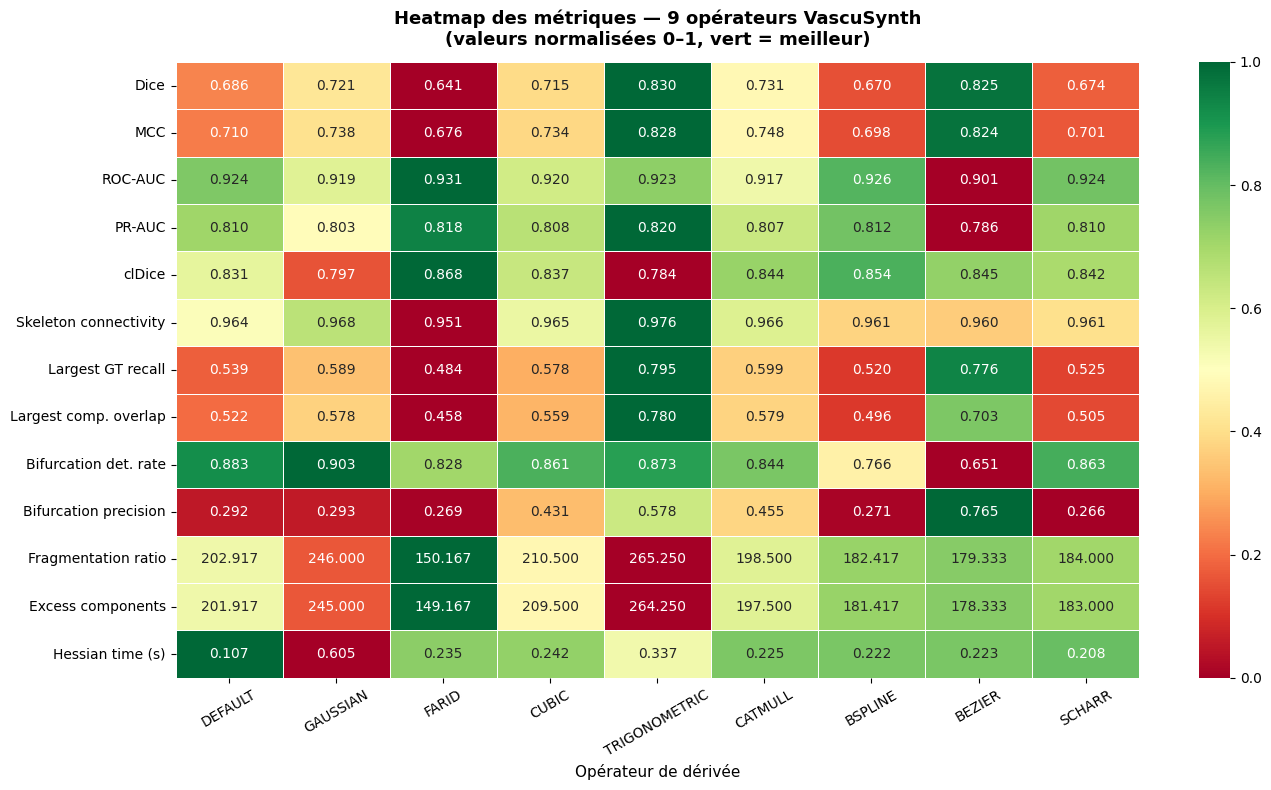

In [10]:
fig, ax = plt.subplots(figsize=(14, 8))

# Métriques pour la heatmap (moyennes)
HM_METRICS = ['dice', 'mcc', 'roc', 'pr', 'cldice',
               'skeleton_component_connectivity', 'largest_gt_recall',
               'largest_component_overlap', 'bifurcation_detection_rate',
               'bifurcation_precision', 'fragmentation_ratio',
               'excess_components', 'hessian_time_seconds']

hm_data = df_mean[HM_METRICS].copy()

# Normaliser 0–1 par colonne (en tenant compte de la direction)
hm_norm = hm_data.copy()
for col in hm_norm.columns:
    col_min, col_max = hm_norm[col].min(), hm_norm[col].max()
    if col_max - col_min > 1e-10:
        hm_norm[col] = (hm_norm[col] - col_min) / (col_max - col_min)
        # Inverser si "moins = meilleur"
        if HIGHER_BETTER.get(col) == False:
            hm_norm[col] = 1 - hm_norm[col]
    else:
        hm_norm[col] = 0.5

hm_labels = [METRIC_LABELS.get(m, m) for m in HM_METRICS]
sns.heatmap(
    hm_norm.T,
    annot=hm_data.T.applymap(lambda x: f"{x:.3f}"),
    fmt='', cmap='RdYlGn', vmin=0, vmax=1,
    linewidths=0.5, linecolor='white',
    xticklabels=[m.upper() for m in hm_norm.index],
    yticklabels=hm_labels,
    ax=ax
)
ax.set_title(
    "Heatmap des métriques — 9 opérateurs VascuSynth\n"
    "(valeurs normalisées 0–1, vert = meilleur)",
    fontsize=13, fontweight='bold', pad=12
)
ax.set_xlabel("Opérateur de dérivée", fontsize=11)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

### 7b. Boxplots — métriques clés sur les 12 volumes

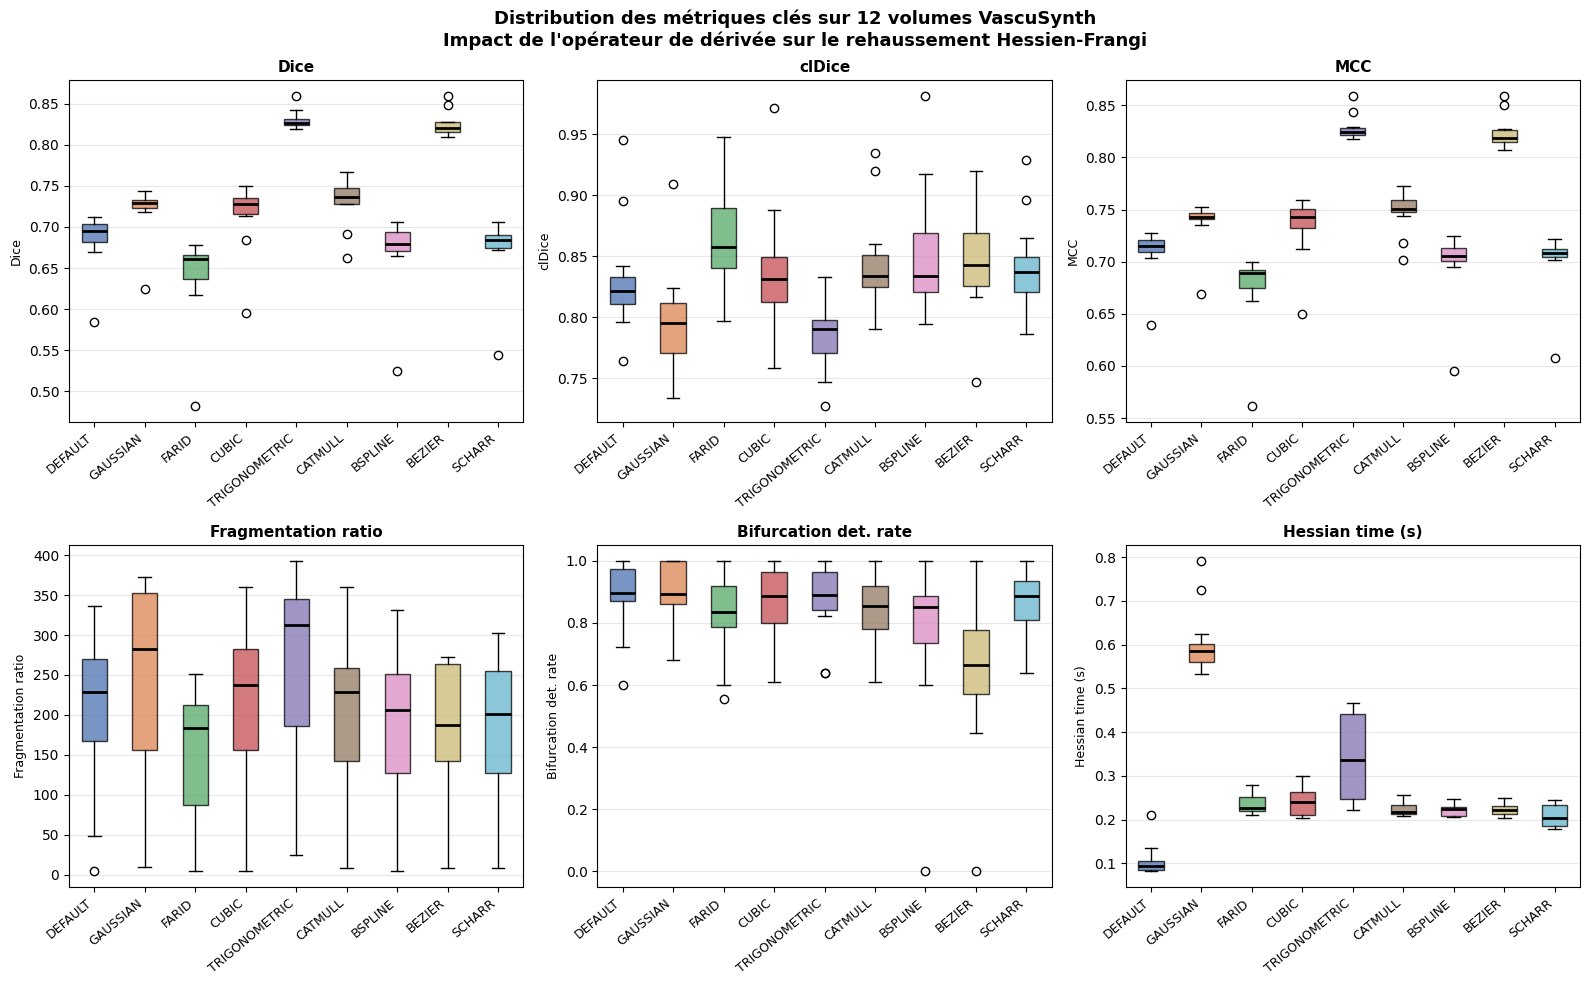

In [11]:
BOXPLOT_METRICS = [
    ('dice',   'Dice'),
    ('cldice', 'clDice'),
    ('mcc',    'MCC'),
    ('fragmentation_ratio', 'Fragmentation ratio'),
    ('bifurcation_detection_rate', 'Bifurcation det. rate'),
    ('hessian_time_seconds', 'Hessian time (s)'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for ax, (metric, label) in zip(axes, BOXPLOT_METRICS):
    data_per_method = []
    labels = []
    colors = []
    for method in METHODS:
        vals = [m[metric] for m in RAW_METRICS[method] if m is not None and metric in m and m[metric] is not None]
        if vals:
            data_per_method.append(vals)
            labels.append(method.upper())
            colors.append(METHOD_COLORS.get(method, '#888888'))

    bp = ax.boxplot(data_per_method, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=9)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel(label, fontsize=9)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle(
    "Distribution des métriques clés sur 12 volumes VascuSynth\n"
    "Impact de l'opérateur de dérivée sur le rehaussement Hessien-Frangi",
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

### 7c. Radar chart — profil de chaque opérateur

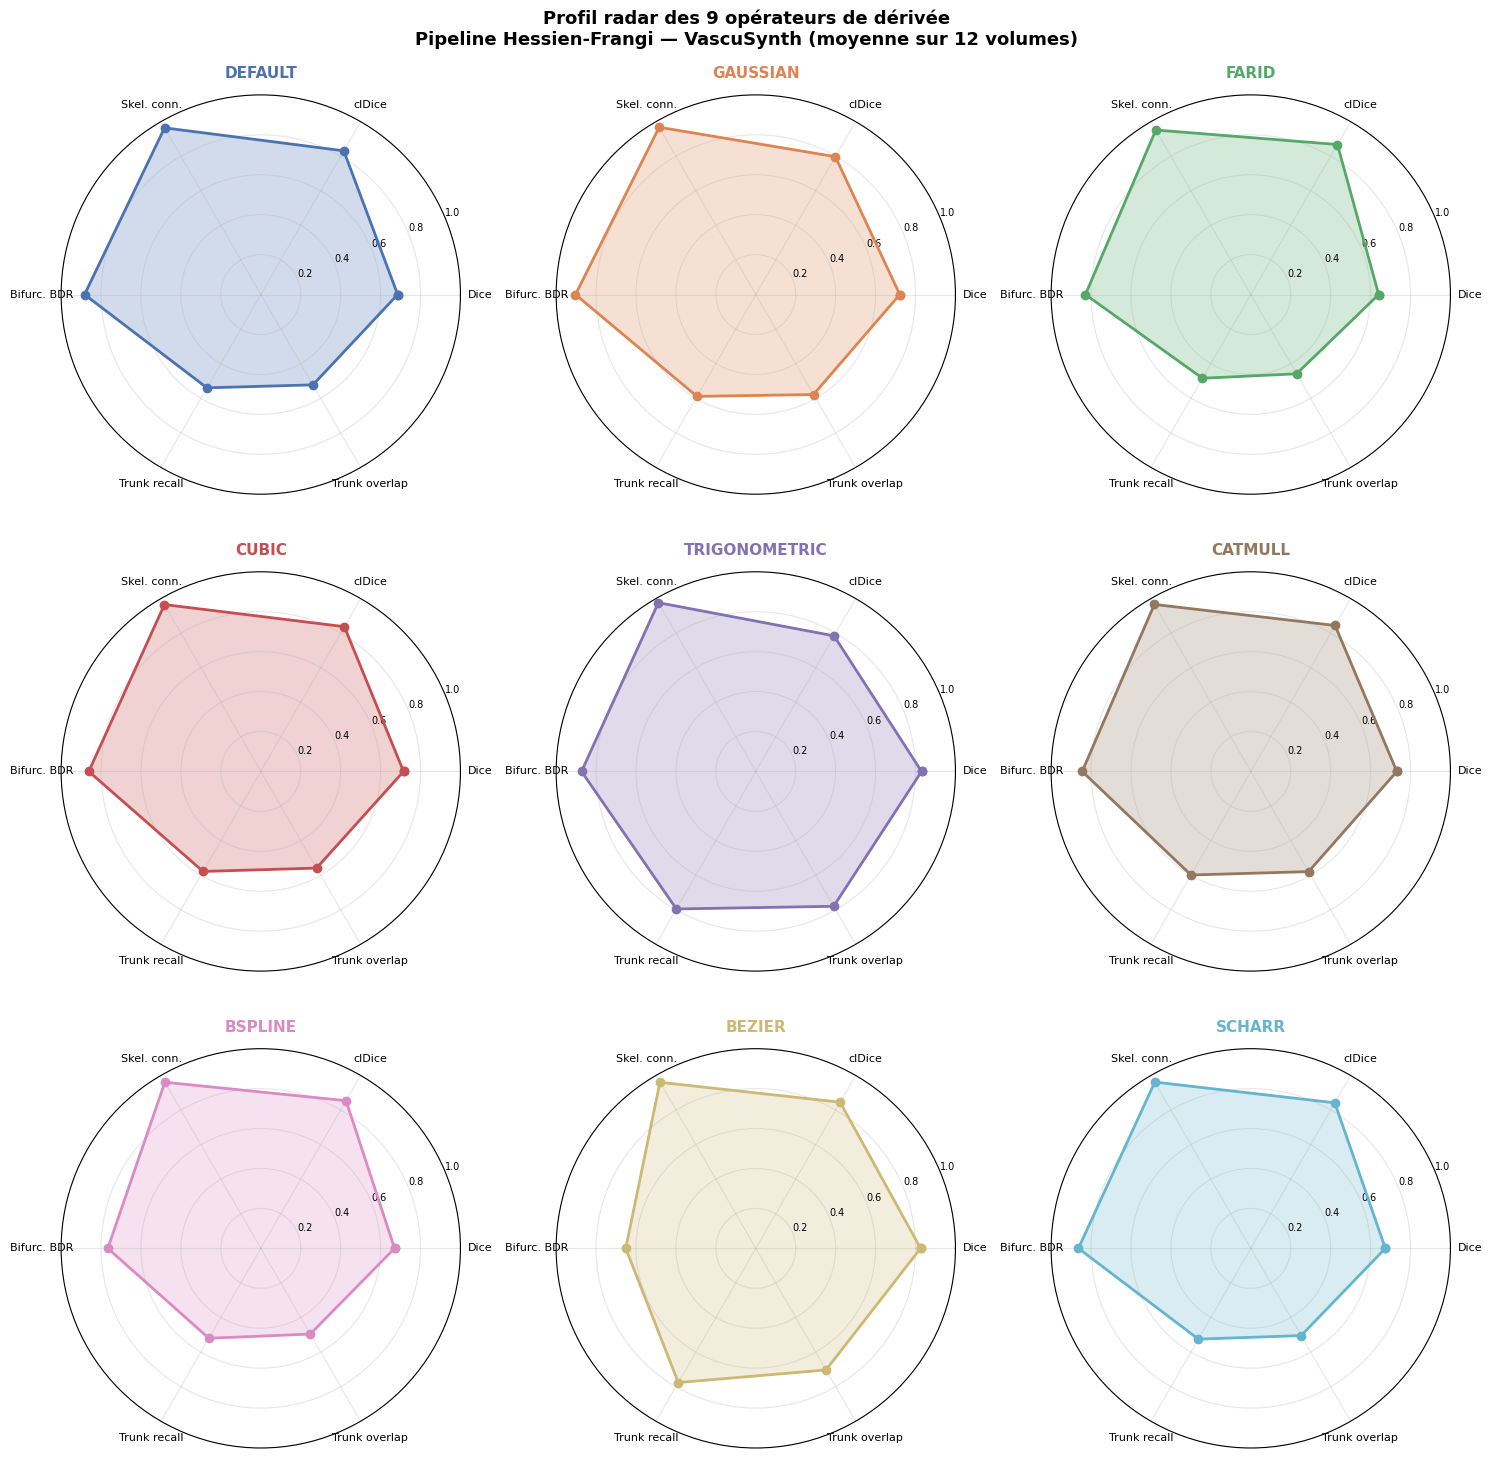

In [12]:
RADAR_METRICS = [
    ('dice',                       'Dice'),
    ('cldice',                     'clDice'),
    ('skeleton_component_connectivity', 'Skel. conn.'),
    ('bifurcation_detection_rate', 'Bifurc. BDR'),
    ('largest_gt_recall',          'Trunk recall'),
    ('largest_component_overlap',  'Trunk overlap'),
]

N = len(RADAR_METRICS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(3, 3, figsize=(15, 15), subplot_kw=dict(polar=True))
axes = axes.ravel()

for ax, method in zip(axes, METHODS):
    valid = [m for m in RAW_METRICS[method] if m is not None]
    if not valid:
        ax.set_visible(False)
        continue

    means = []
    for key, _ in RADAR_METRICS:
        vals = [m[key] for m in valid if key in m and m[key] is not None]
        means.append(float(np.mean(vals)) if vals else 0.0)
    means += means[:1]

    color = METHOD_COLORS.get(method, '#888888')
    ax.plot(angles, means, 'o-', linewidth=2, color=color)
    ax.fill(angles, means, alpha=0.25, color=color)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([lbl for _, lbl in RADAR_METRICS], fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=7)
    ax.set_title(method.upper(), fontsize=11, fontweight='bold',
                 color=color, pad=12)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    "Profil radar des 9 opérateurs de dérivée\n"
    "Pipeline Hessien-Frangi — VascuSynth (moyenne sur 12 volumes)",
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

### 7d. Scatter : Dice vs clDice — compromis volumétrique/topologique

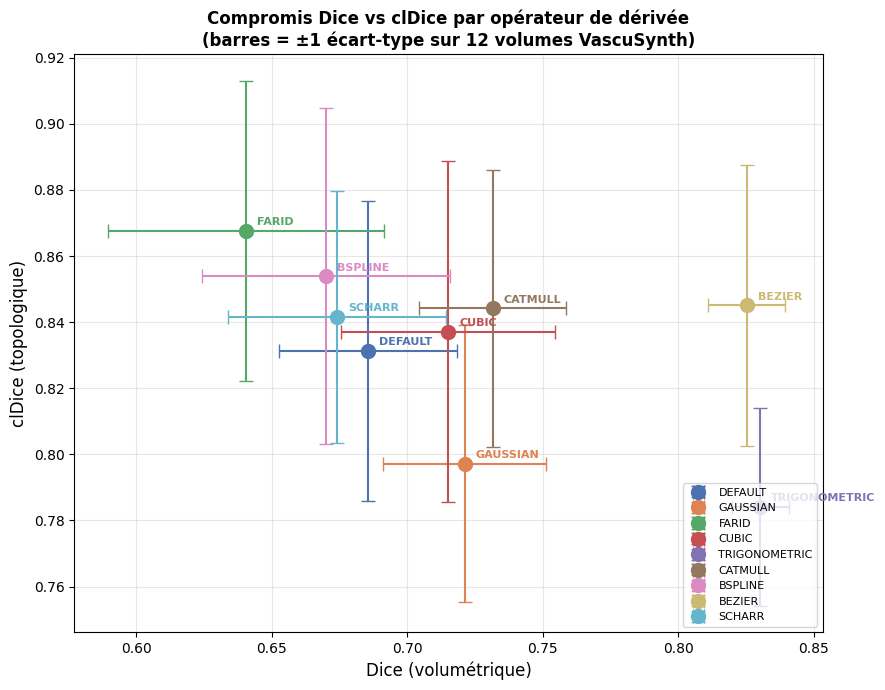

In [13]:
fig, ax = plt.subplots(figsize=(9, 7))

for method in METHODS:
    valid = [m for m in RAW_METRICS[method] if m is not None]
    if not valid:
        continue
    dice_m  = np.mean([m['dice']   for m in valid if 'dice'   in m])
    cldice_m = np.mean([m['cldice'] for m in valid if 'cldice' in m])
    dice_s  = np.std([m['dice']   for m in valid if 'dice'   in m])
    cldice_s = np.std([m['cldice'] for m in valid if 'cldice' in m])

    color = METHOD_COLORS.get(method, '#888')
    ax.errorbar(dice_m, cldice_m, xerr=dice_s, yerr=cldice_s,
                fmt='o', color=color, markersize=10,
                elinewidth=1.5, capsize=5, label=method.upper())
    ax.annotate(method.upper(), (dice_m, cldice_m),
                textcoords="offset points", xytext=(8, 4),
                fontsize=8, color=color, fontweight='bold')

ax.set_xlabel("Dice (volumétrique)", fontsize=12)
ax.set_ylabel("clDice (topologique)", fontsize=12)
ax.set_title(
    "Compromis Dice vs clDice par opérateur de dérivée\n"
    "(barres = ±1 écart-type sur 12 volumes VascuSynth)",
    fontsize=12, fontweight='bold'
)
ax.grid(alpha=0.3)
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

### 7e. Temps d'exécution du calcul Hessien

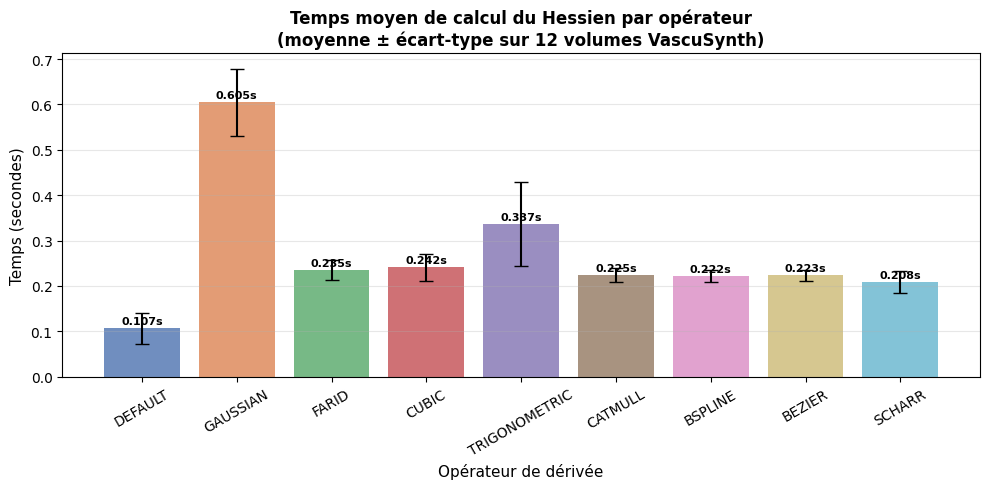

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

means_t = [np.mean([t for t in HESSIAN_TIMES[m] if t is not None]) for m in METHODS]
stds_t  = [np.std([t  for t in HESSIAN_TIMES[m] if t is not None]) for m in METHODS]
colors_t = [METHOD_COLORS.get(m, '#888') for m in METHODS]
labels_t = [m.upper() for m in METHODS]

bars = ax.bar(labels_t, means_t, yerr=stds_t, color=colors_t,
              alpha=0.8, capsize=5, error_kw=dict(elinewidth=1.5))
ax.set_ylabel("Temps (secondes)", fontsize=11)
ax.set_xlabel("Opérateur de dérivée", fontsize=11)
ax.set_title(
    "Temps moyen de calcul du Hessien par opérateur\n"
    "(moyenne ± écart-type sur 12 volumes VascuSynth)",
    fontsize=12, fontweight='bold'
)
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)

for bar, mean_v in zip(bars, means_t):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(stds_t)*0.05,
            f"{mean_v:.3f}s", ha='center', va='bottom', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.show()

            MATRICE DE CONFUSION — MOYENNE ± ÉCART-TYPE (12 volumes)            
Méthode                          TP                 FP                 FN                 TN
--------------------------------------------------------------------------------
DEFAULT                10480±5334           684±393           8392±3974       1010745±9677  
GAUSSIAN               11380±5733           885±483           7491±3570       1010545±9768  
FARID                   9529±4891           507±332           9343±4422       1010922±9609  
CUBIC                  11226±5656           759±430           7645±3677       1010670±9695  
TRIGONOMETRIC          14947±7260          2301±1077          3925±2048       1009129±10346 
CATMULL                11552±5788           776±444           7320±3554       1010654±9703  
BSPLINE                10150±5156           616±382           8722±4160       1010814±9656  
BEZIER                 14483±6936          1943±872           4389±2379       1009486±10141 
S

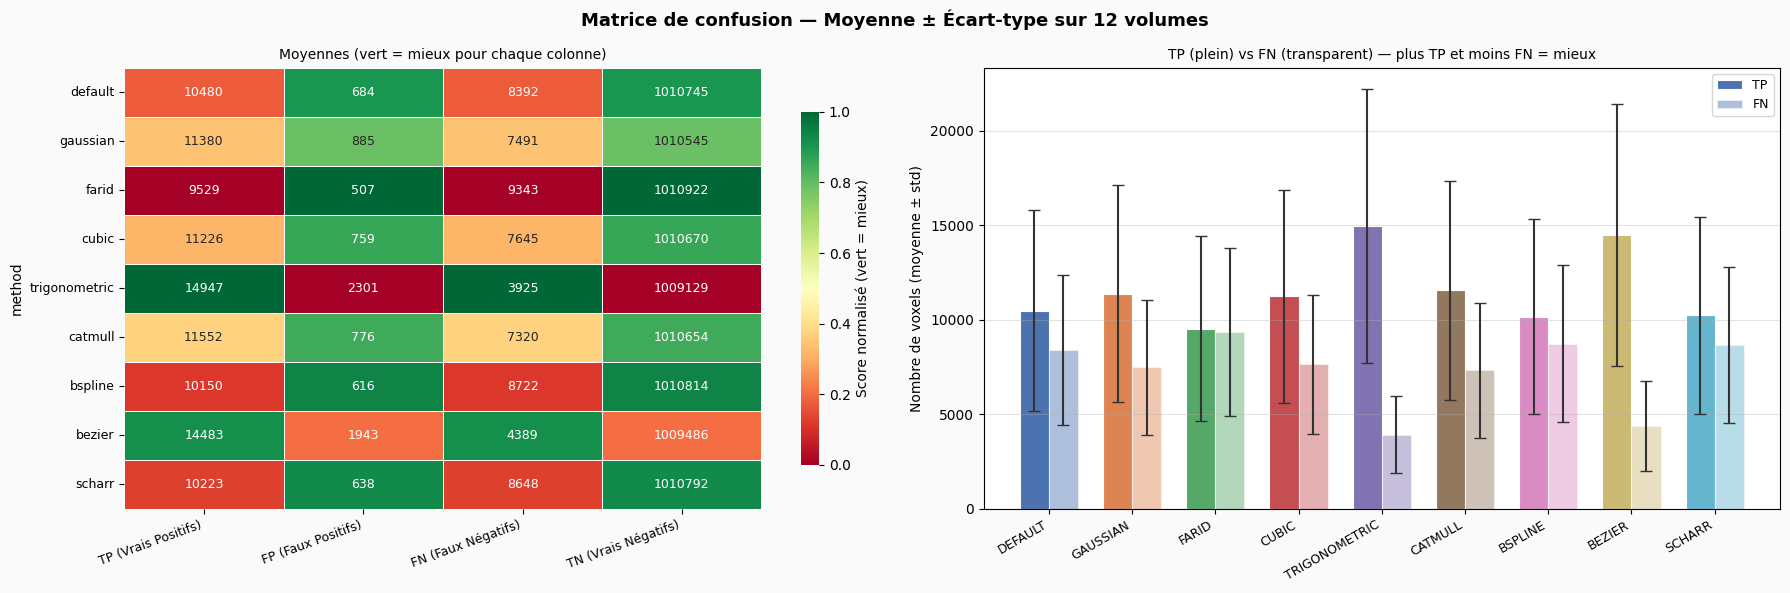


DataFrame matrice de confusion (accès programmatique) :
               tp_mean  tp_std  fp_mean  fp_std  fn_mean  fn_std  tn_mean  tn_std
method                                                                           
default          10480    5334      684     393     8392    3974  1010745    9677
gaussian         11380    5733      885     483     7491    3570  1010545    9768
farid             9529    4891      507     332     9343    4422  1010922    9609
cubic            11226    5656      759     430     7645    3677  1010670    9695
trigonometric    14947    7260     2301    1077     3925    2048  1009129   10346
catmull          11552    5788      776     444     7320    3554  1010654    9703
bspline          10150    5156      616     382     8722    4160  1010814    9656
bezier           14483    6936     1943     872     4389    2379  1009486   10141
scharr           10223    5192      638     383     8648    4116  1010792    9662


In [15]:
# ─── Matrice de confusion — Moyenne ± Écart-type sur 12 volumes ──────────────

CM_KEYS = ['tp', 'fp', 'fn', 'tn']
CM_LABELS = {'tp': 'TP (Vrais Positifs)',
             'fp': 'FP (Faux Positifs)',
             'fn': 'FN (Faux Négatifs)',
             'tn': 'TN (Vrais Négatifs)'}

# ── 1. Tableau numérique ──────────────────────────────────────────────────────
print("=" * 80)
print(f"{'MATRICE DE CONFUSION — MOYENNE ± ÉCART-TYPE (12 volumes)':^80}")
print("=" * 80)
print(f"{'Méthode':<16} {'TP':>18} {'FP':>18} {'FN':>18} {'TN':>18}")
print("-" * 80)

cm_rows = []
for method in METHODS:
    valid = [m for m in RAW_METRICS[method] if m is not None]
    row = {'method': method}
    for k in CM_KEYS:
        vals = [m[k] for m in valid if k in m]
        row[f'{k}_mean'] = float(np.mean(vals)) if vals else np.nan
        row[f'{k}_std']  = float(np.std(vals))  if vals else np.nan
    cm_rows.append(row)
    print(
        f"{method.upper():<16}"
        f"  {row['tp_mean']:>10.0f}±{row['tp_std']:<6.0f}"
        f"  {row['fp_mean']:>10.0f}±{row['fp_std']:<6.0f}"
        f"  {row['fn_mean']:>10.0f}±{row['fn_std']:<6.0f}"
        f"  {row['tn_mean']:>10.0f}±{row['tn_std']:<6.0f}"
    )

print("=" * 80)
df_cm = pd.DataFrame(cm_rows).set_index('method')

# ── 2. Visualisation — Heatmap + Barplots ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6), facecolor='#FAFAFA')
fig.suptitle(
    "Matrice de confusion — Moyenne ± Écart-type sur 12 volumes",
    fontsize=13, fontweight='bold'
)

# Panel gauche : heatmap des moyennes
ax_heat = axes[0]
heat_data = df_cm[[f'{k}_mean' for k in CM_KEYS]].copy()
heat_data.columns = [CM_LABELS[k] for k in CM_KEYS]

# Normaliser par colonne pour la couleur (valeurs réelles annotées)
heat_norm = (heat_data - heat_data.min()) / (heat_data.max() - heat_data.min() + 1e-9)

# Pour FP et FN : un score bas est mieux → inverser la normalisation
for lbl in ['FP (Faux Positifs)', 'FN (Faux Négatifs)']:
    heat_norm[lbl] = 1 - heat_norm[lbl]

import seaborn as sns
sns.heatmap(
    heat_norm,
    annot=heat_data.round(0).astype(int),
    fmt='d',
    cmap='RdYlGn',
    linewidths=0.6,
    linecolor='white',
    ax=ax_heat,
    annot_kws={'size': 9},
    cbar_kws={'label': 'Score normalisé (vert = mieux)', 'shrink': 0.8},
    vmin=0, vmax=1,
)
ax_heat.set_title("Moyennes (vert = mieux pour chaque colonne)", fontsize=10)
ax_heat.set_yticklabels(ax_heat.get_yticklabels(), rotation=0, fontsize=9)
ax_heat.set_xticklabels(ax_heat.get_xticklabels(), rotation=20, ha='right', fontsize=9)

# Panel droit : barplot TP et FN côte à côte (les plus informatifs cliniquement)
ax_bar = axes[1]
x = np.arange(len(METHODS))
width = 0.35

tp_means = [df_cm.loc[m, 'tp_mean'] for m in METHODS]
tp_stds  = [df_cm.loc[m, 'tp_std']  for m in METHODS]
fn_means = [df_cm.loc[m, 'fn_mean'] for m in METHODS]
fn_stds  = [df_cm.loc[m, 'fn_std']  for m in METHODS]

bars_tp = ax_bar.bar(
    x - width/2, tp_means, width,
    yerr=tp_stds, label='TP',
    color=[METHOD_COLORS[m] for m in METHODS],
    edgecolor='white', linewidth=0.8,
    error_kw={'capsize': 4, 'elinewidth': 1.5, 'ecolor': '#333333'}
)
bars_fn = ax_bar.bar(
    x + width/2, fn_means, width,
    yerr=fn_stds, label='FN',
    color=[METHOD_COLORS[m] for m in METHODS],
    edgecolor='white', linewidth=0.8, alpha=0.45,
    error_kw={'capsize': 4, 'elinewidth': 1.5, 'ecolor': '#333333'}
)

ax_bar.set_xticks(x)
ax_bar.set_xticklabels([m.upper() for m in METHODS], rotation=30, ha='right', fontsize=9)
ax_bar.set_ylabel('Nombre de voxels (moyenne ± std)')
ax_bar.set_title("TP (plein) vs FN (transparent) — plus TP et moins FN = mieux", fontsize=10)
ax_bar.legend(fontsize=9)
ax_bar.grid(True, axis='y', alpha=0.35)

plt.tight_layout()
plt.show()

# ── 3. Tableau DataFrame formaté ─────────────────────────────────────────────
print("\nDataFrame matrice de confusion (accès programmatique) :")
with pd.option_context('display.float_format', '{:.0f}'.format,
                       'display.max_columns', None, 'display.width', 160):
    display_cols = []
    for k in CM_KEYS:
        display_cols += [f'{k}_mean', f'{k}_std']
    print(df_cm[display_cols].to_string())


---
## 6. Visualisation des composantes connexes — GT + 8 opérateurs

Pour chaque volume (1 à 12) on affiche une grille 3×3 :  
- **Cellule (0,0)** : GT coloré par CC  
- **Cellules suivantes** : prédiction de chaque opérateur colorée par CC  

Chaque CC reçoit une couleur unique pour rendre immédiatement visible la fragmentation.


In [16]:
def colorize_cc(mask: np.ndarray):
    """
    Retourne un array labelisé, le nombre de composantes et la colormap.
    """
    struct = np.ones((3, 3, 3))
    labeled, n_cc = scipy_label(mask.astype(bool), structure=struct)
    # Palette cyclique tab20
    cmap = plt.get_cmap('tab20', 20)  # 20 couleurs fixes
    return labeled, n_cc, cmap


def make_cc_rgb(slice_2d, cmap, n_cc):
    """Convertit un slice labelisé en image RGB avec fond noir.
    Chaque composante reçoit une couleur UNIQUE et DISTINCTE."""
    h, w = slice_2d.shape
    rgb = np.zeros((h, w, 3))
    
    # Pré-générer les couleurs pour chaque composante
    # Utiliser tab20 cycliquement pour avoir des couleurs bien distinctes
    colors = []
    for i in range(n_cc):
        # Prendre une couleur de tab20 (cycle toutes les 20)
        idx = i % 20
        color = cmap(idx)[:3]  # (R,G,B)
        colors.append(color)
    
    # Colorier chaque pixel selon sa composante
    for lbl in range(1, n_cc + 1):
        mask = slice_2d == lbl
        if mask.any():
            rgb[mask] = colors[lbl - 1]
    
    return rgb


def get_slice(labeled, axis='z', position=None):
    """Coupe 2D d'un volume 3D labelisé."""
    if position is None:
        # Par défaut, prend la coupe médiane
        shape = labeled.shape
        if axis == 'x':
            position = shape[0] // 2
        elif axis == 'y':
            position = shape[1] // 2
        else:
            position = shape[2] // 2
    
    if axis == 'x':
        return labeled[position, :, :].T
    if axis == 'y':
        return labeled[:, position, :].T
    return labeled[:, :, position].T

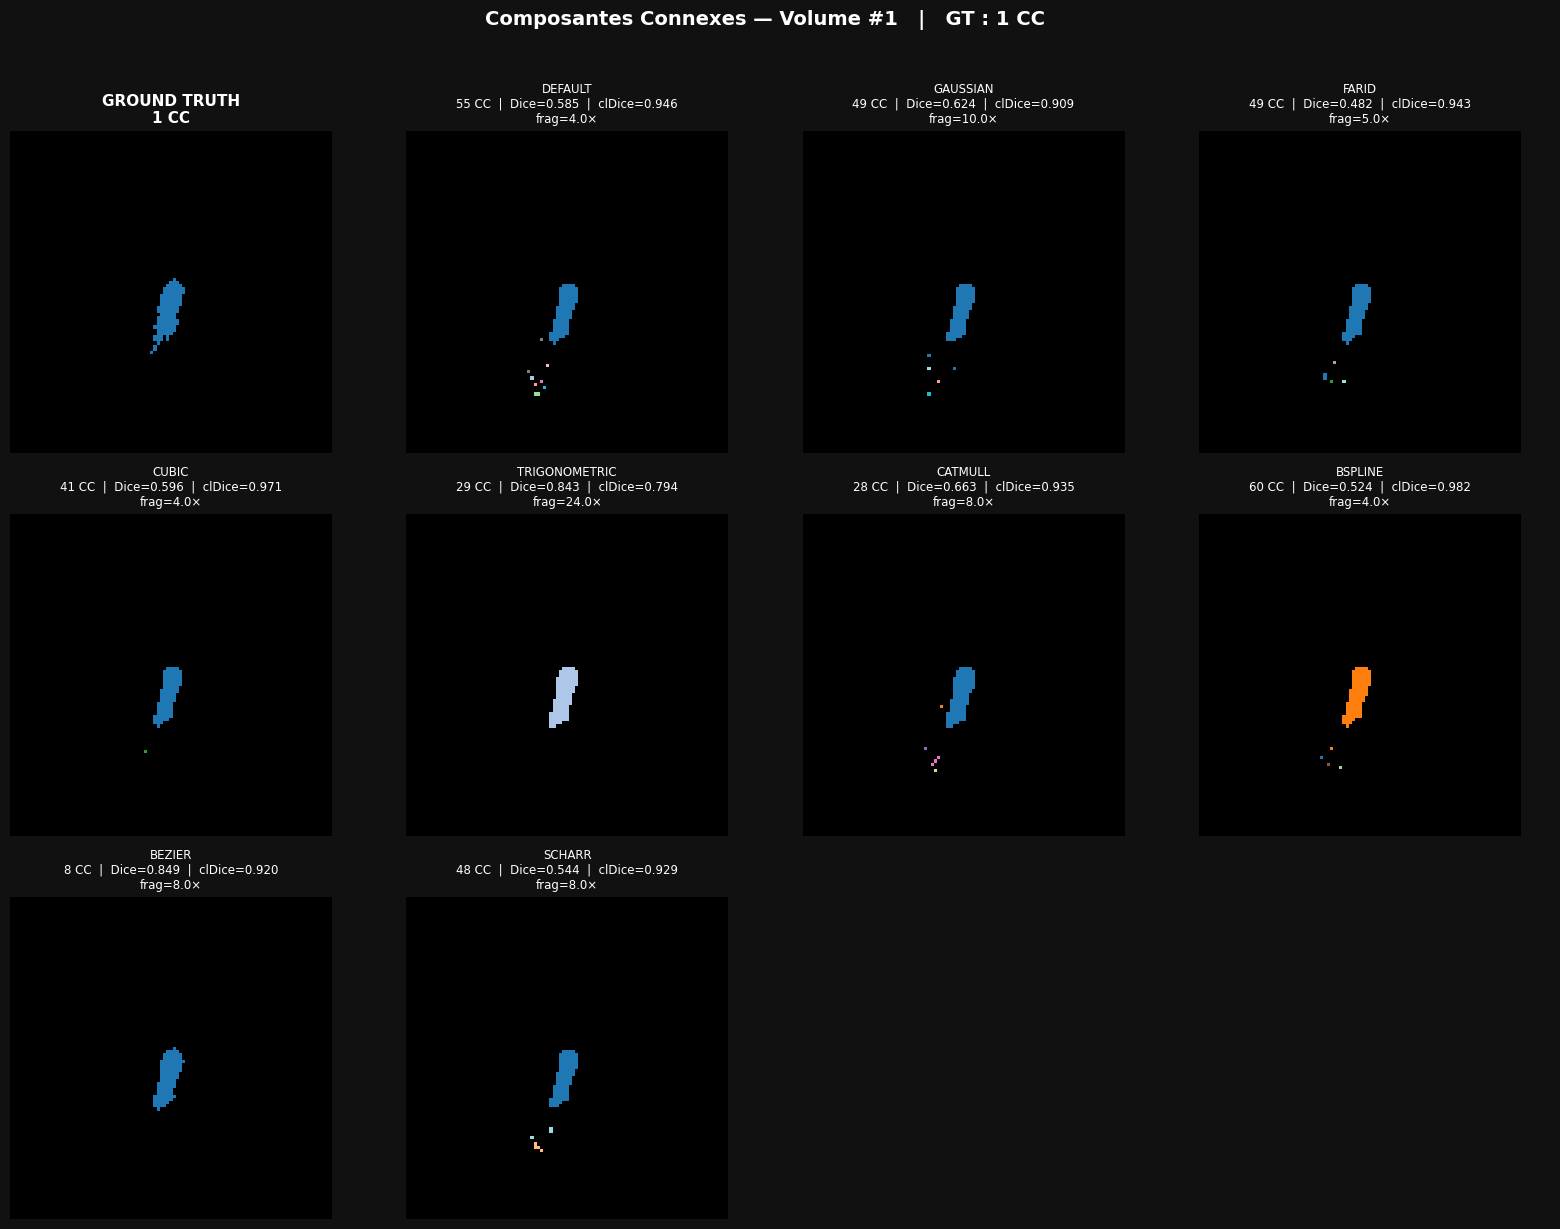

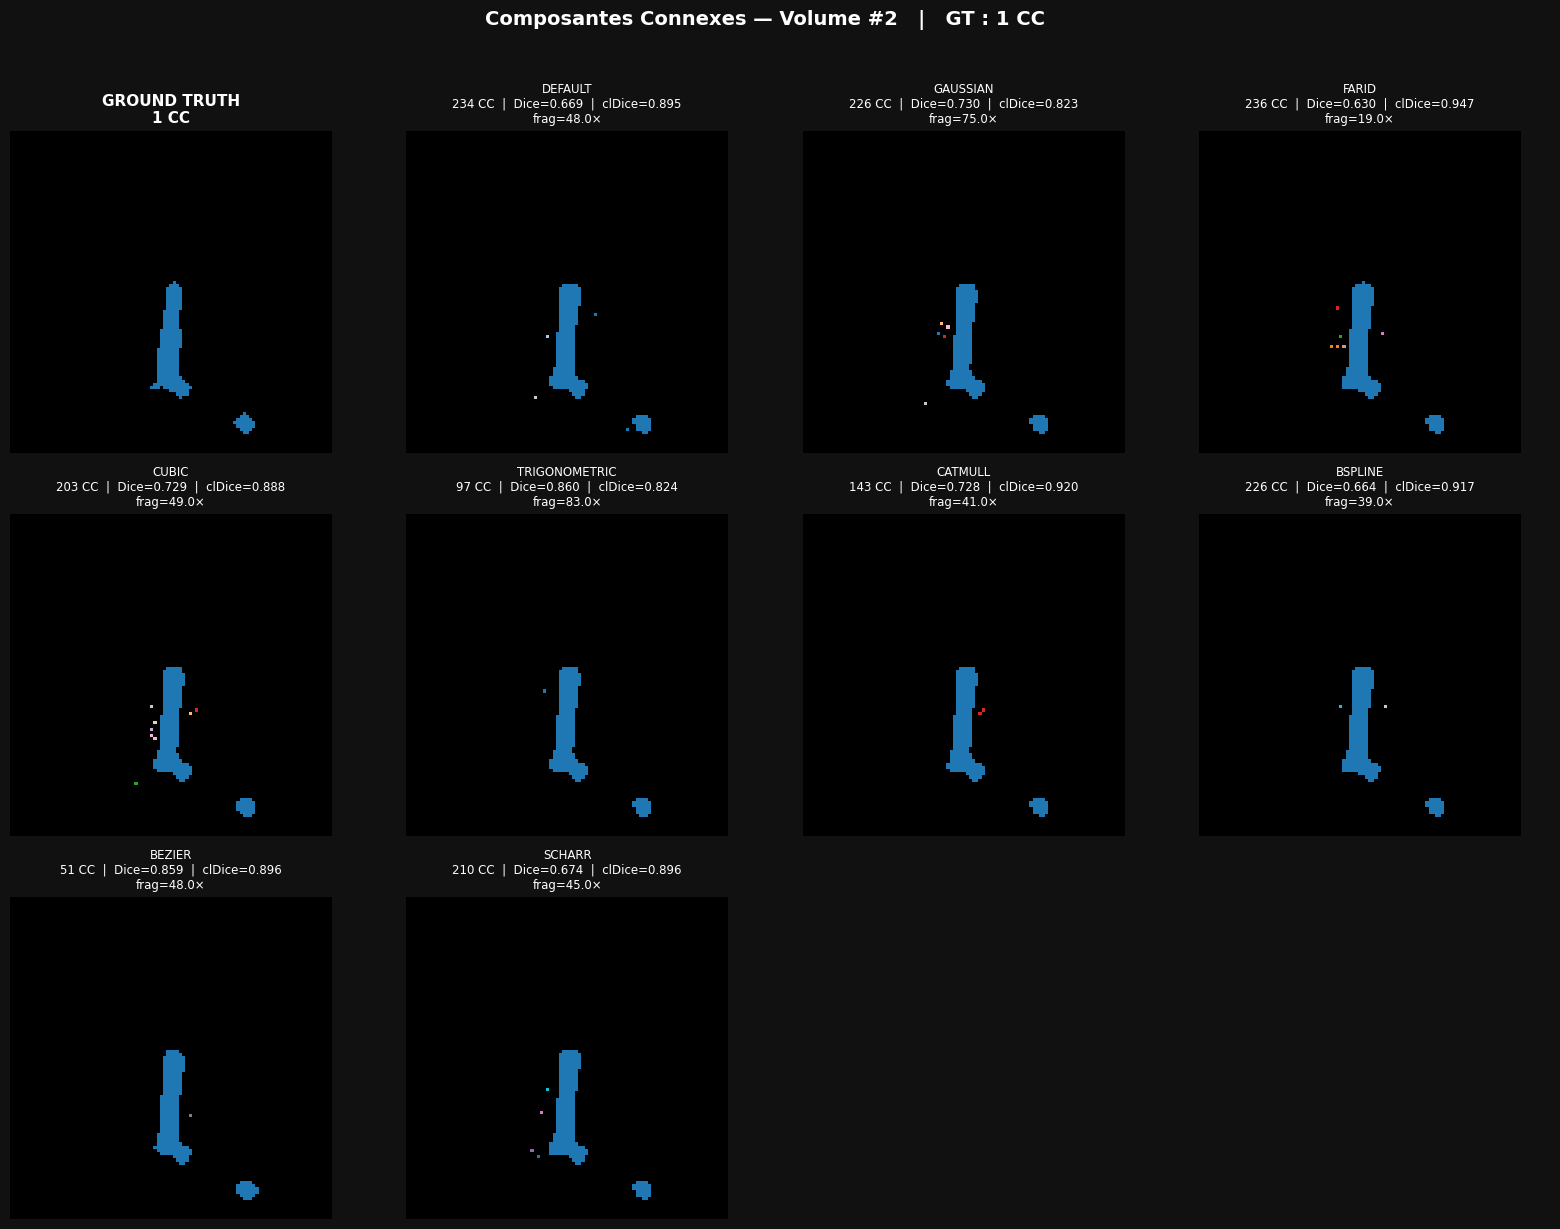

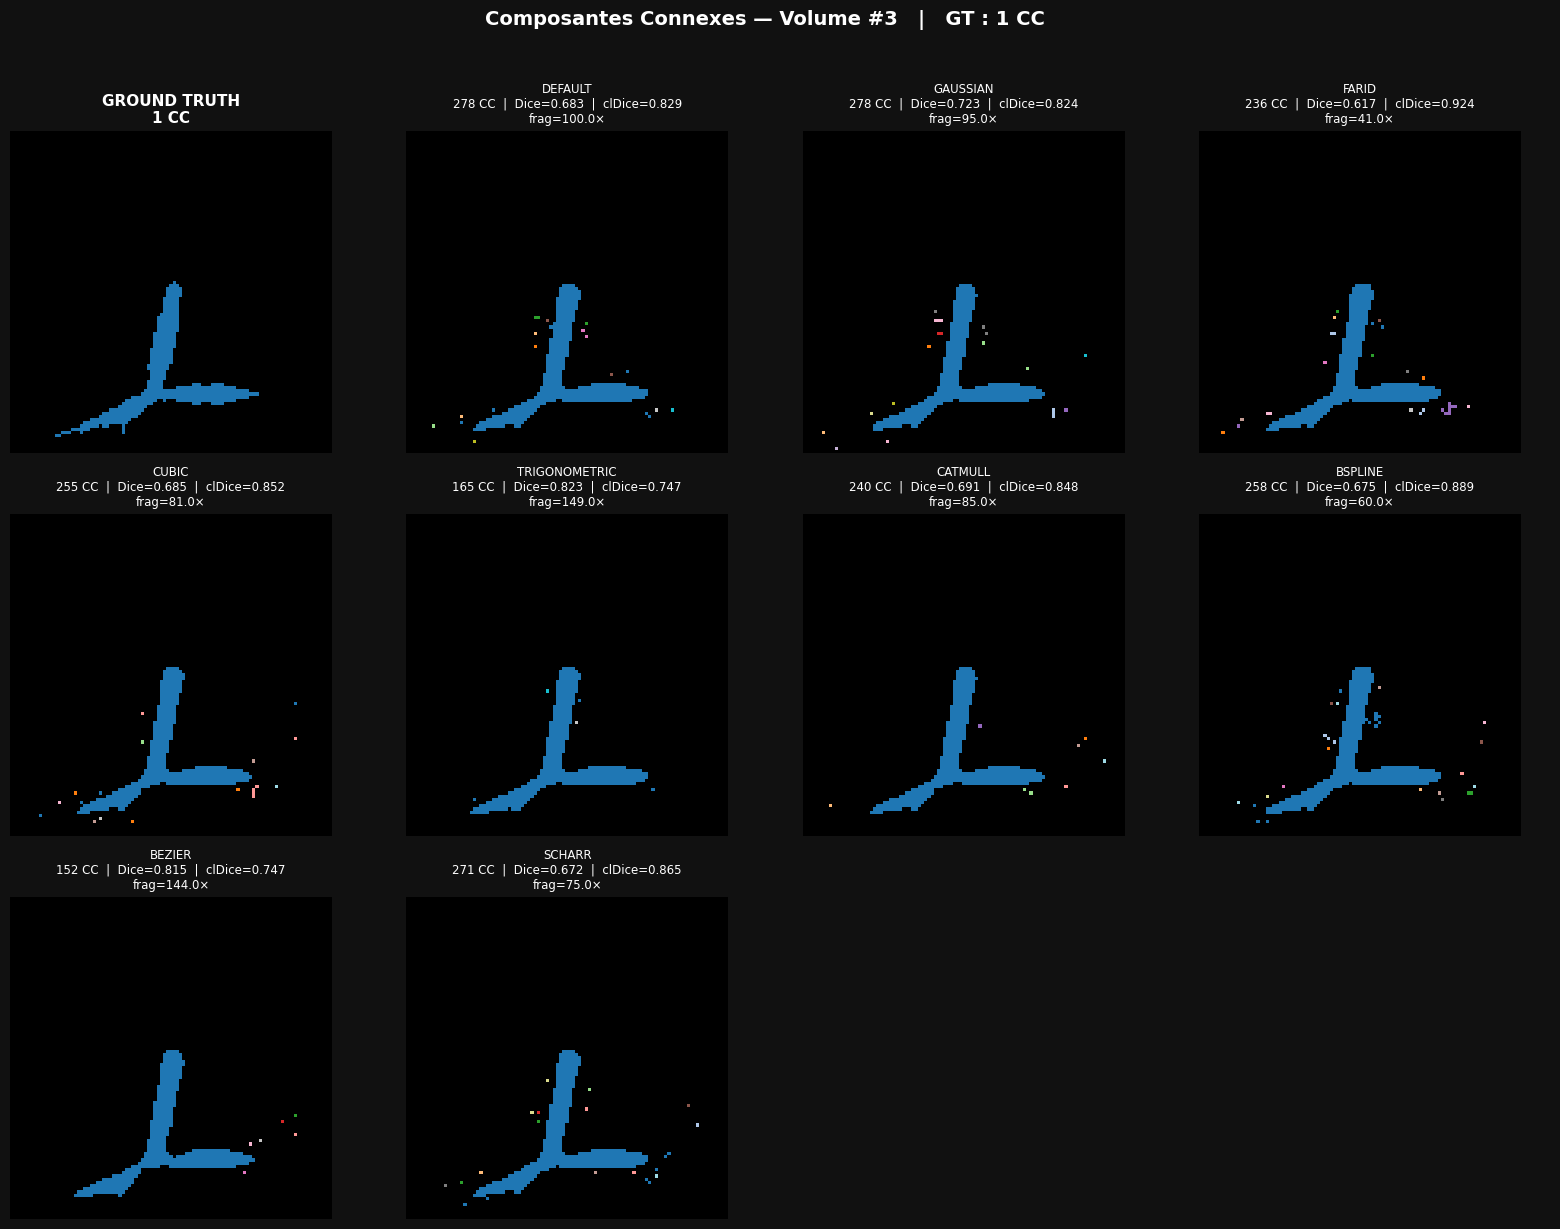

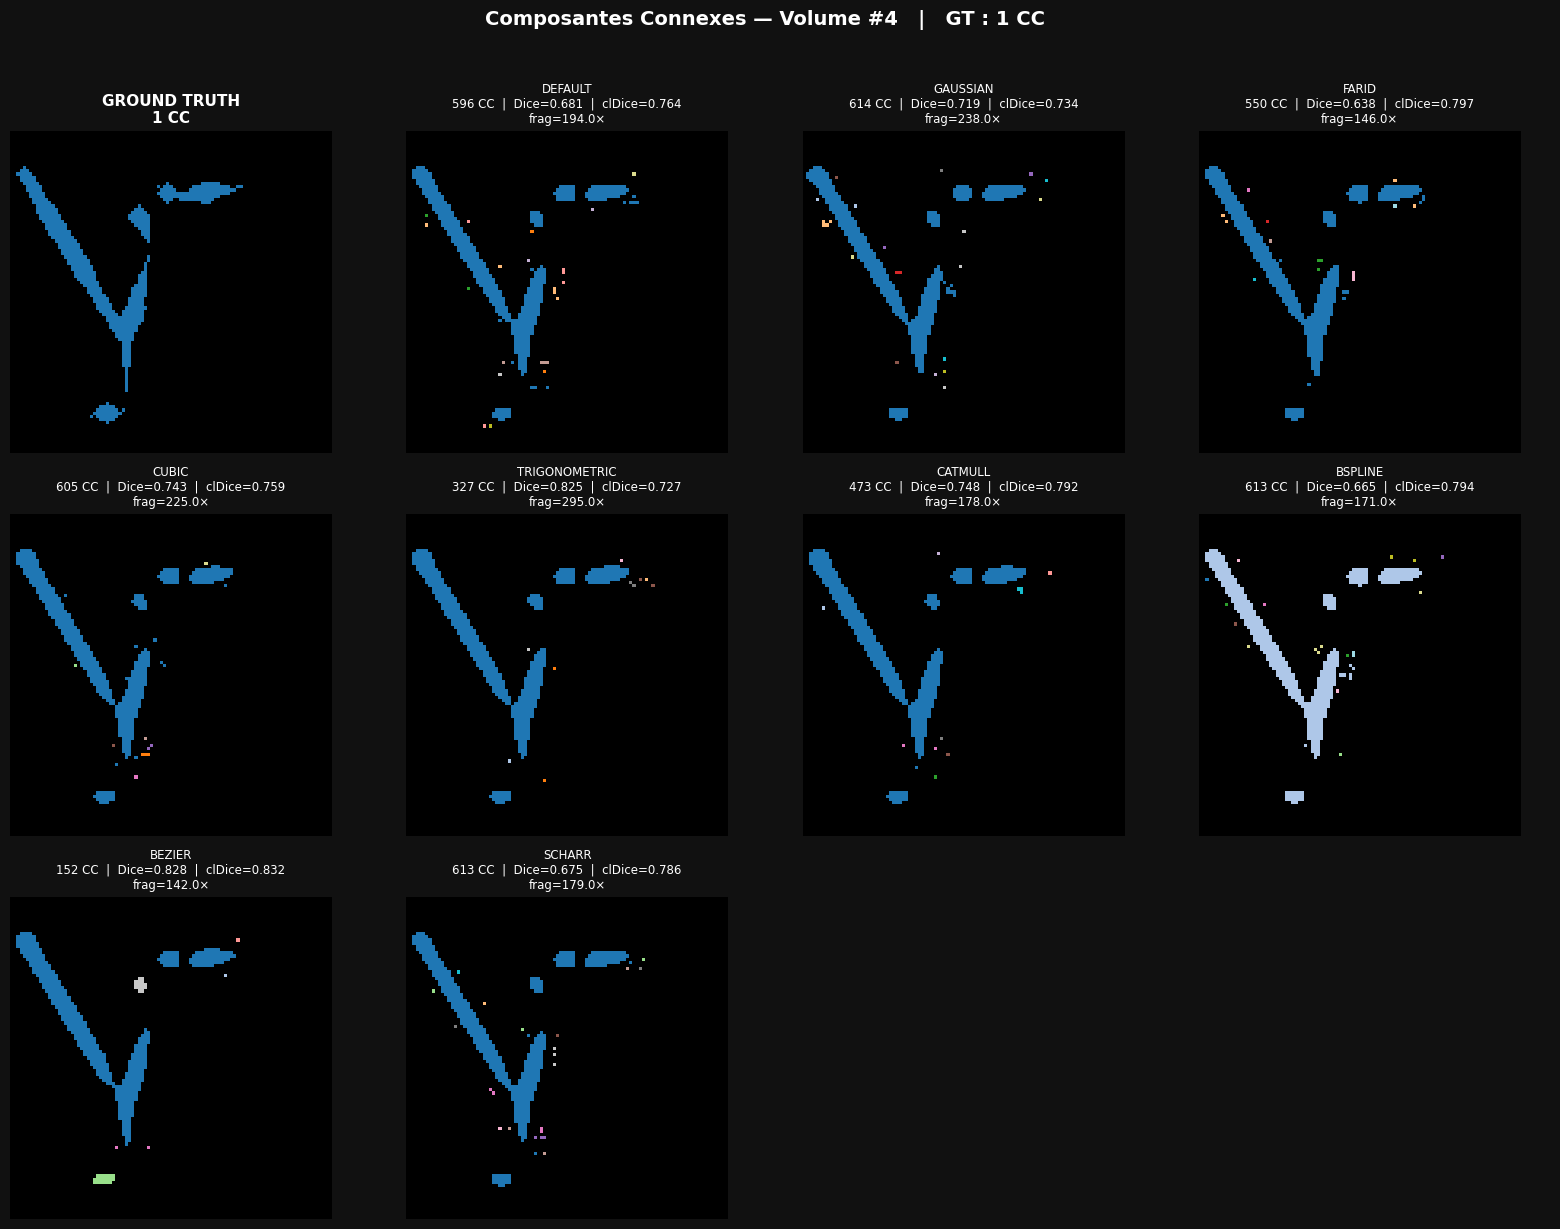

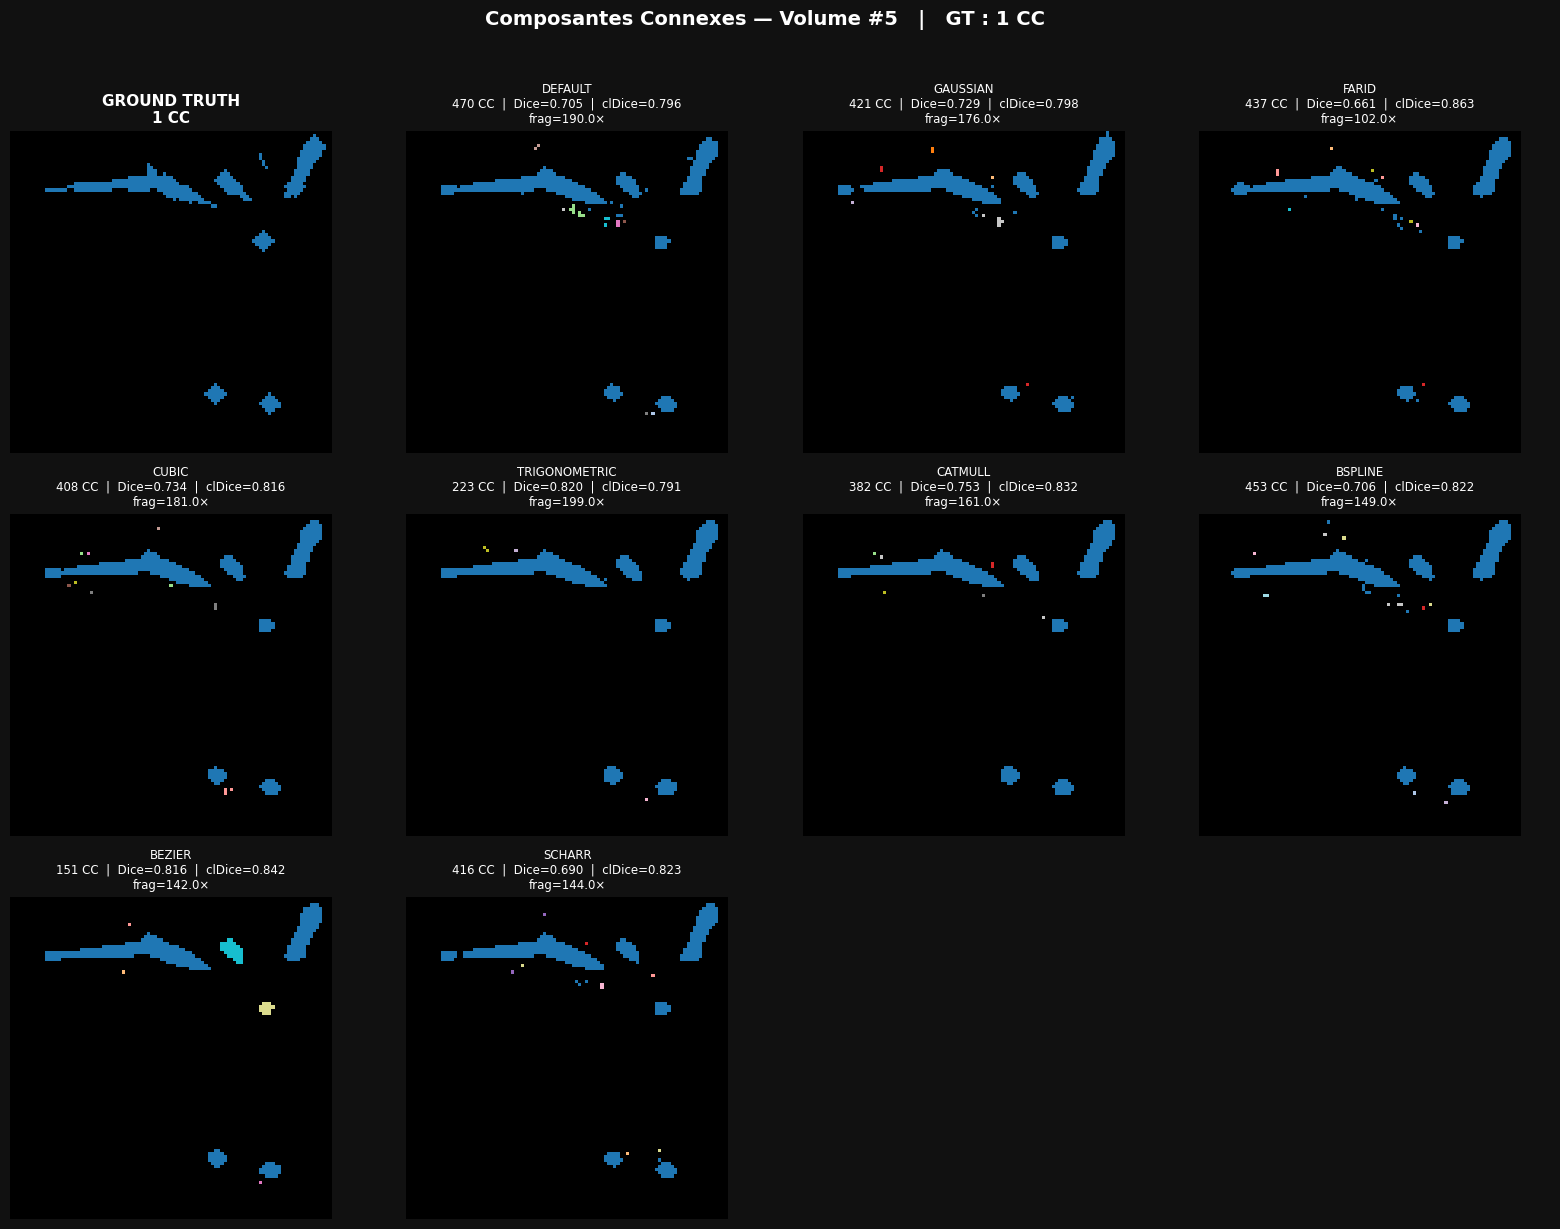

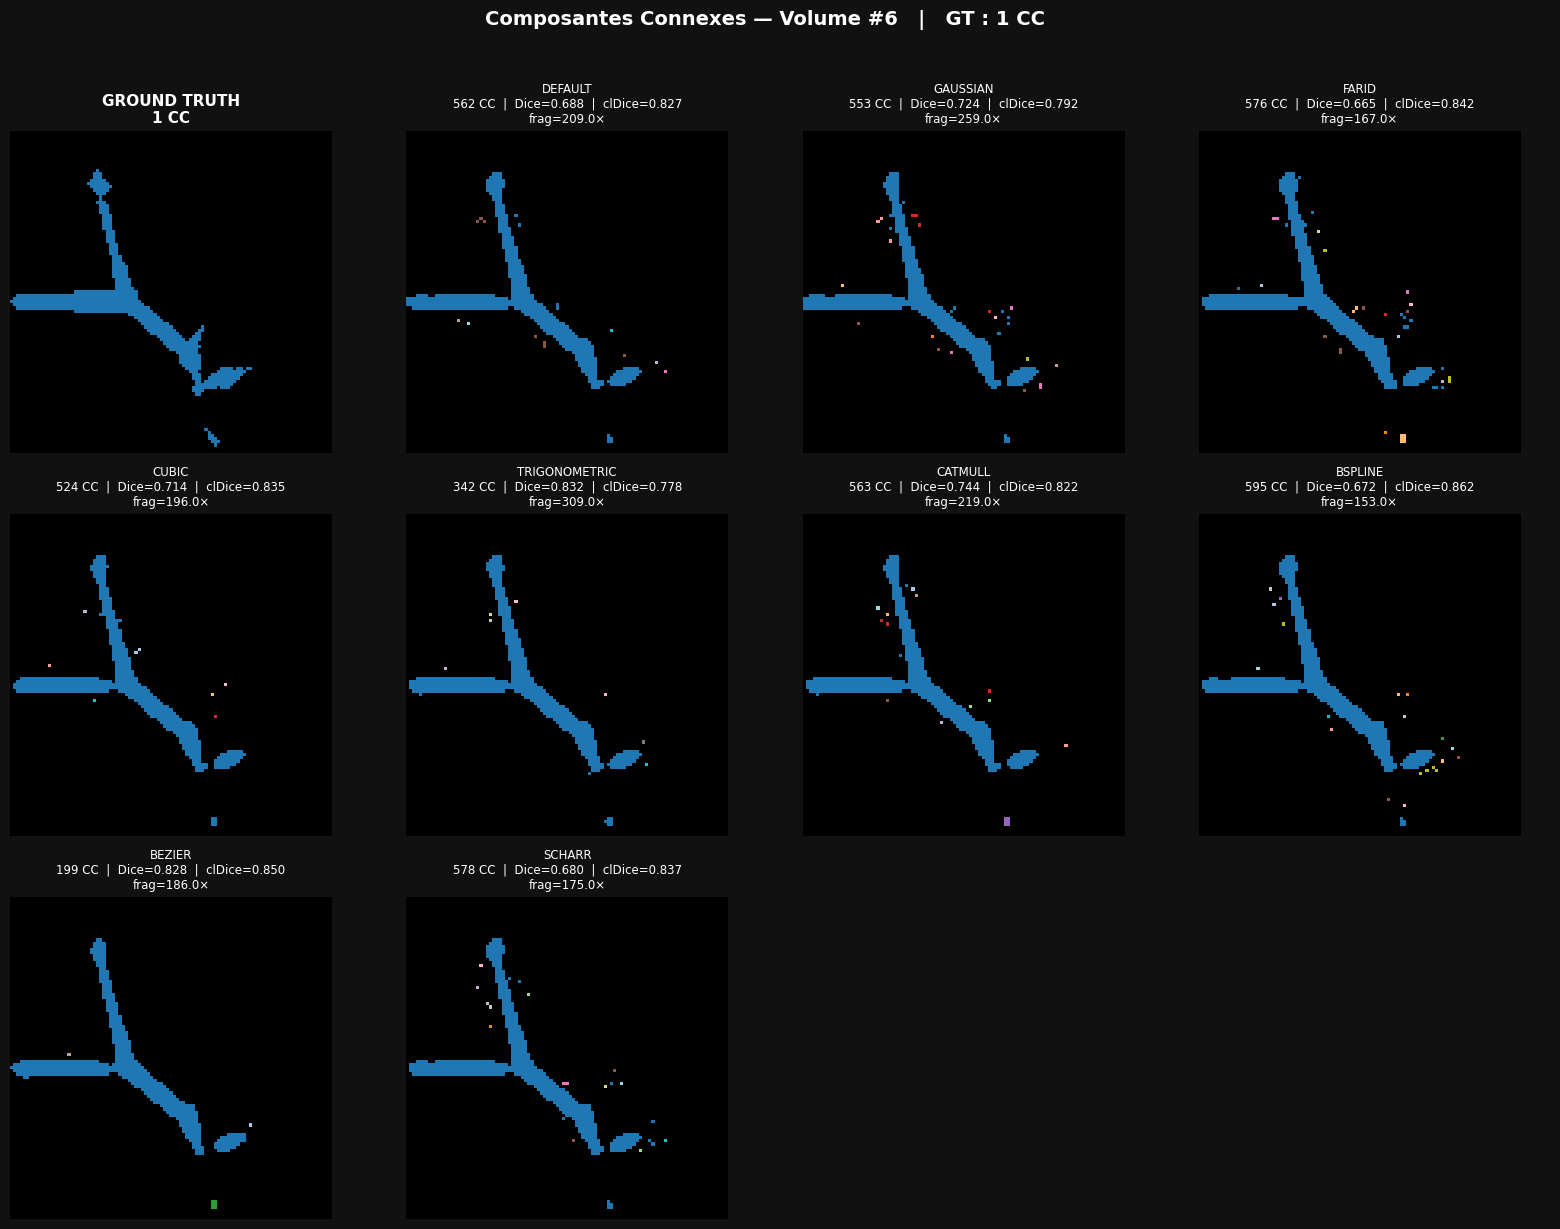

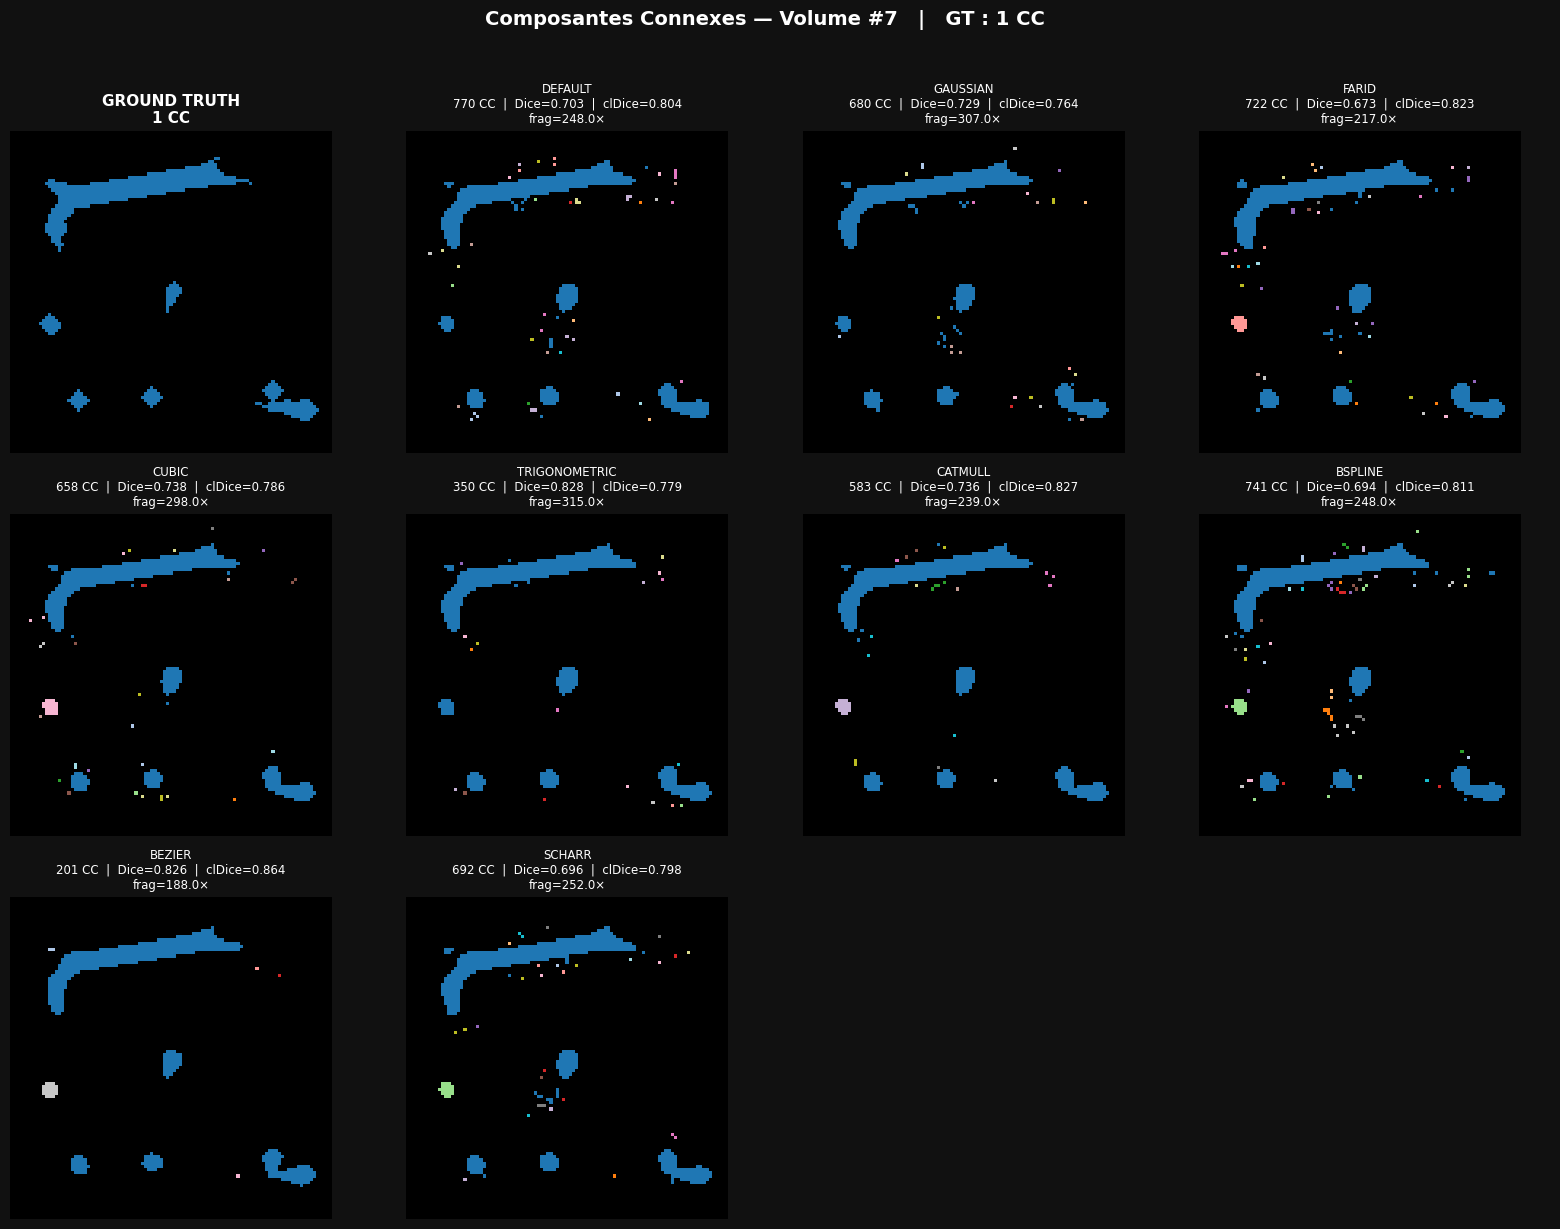

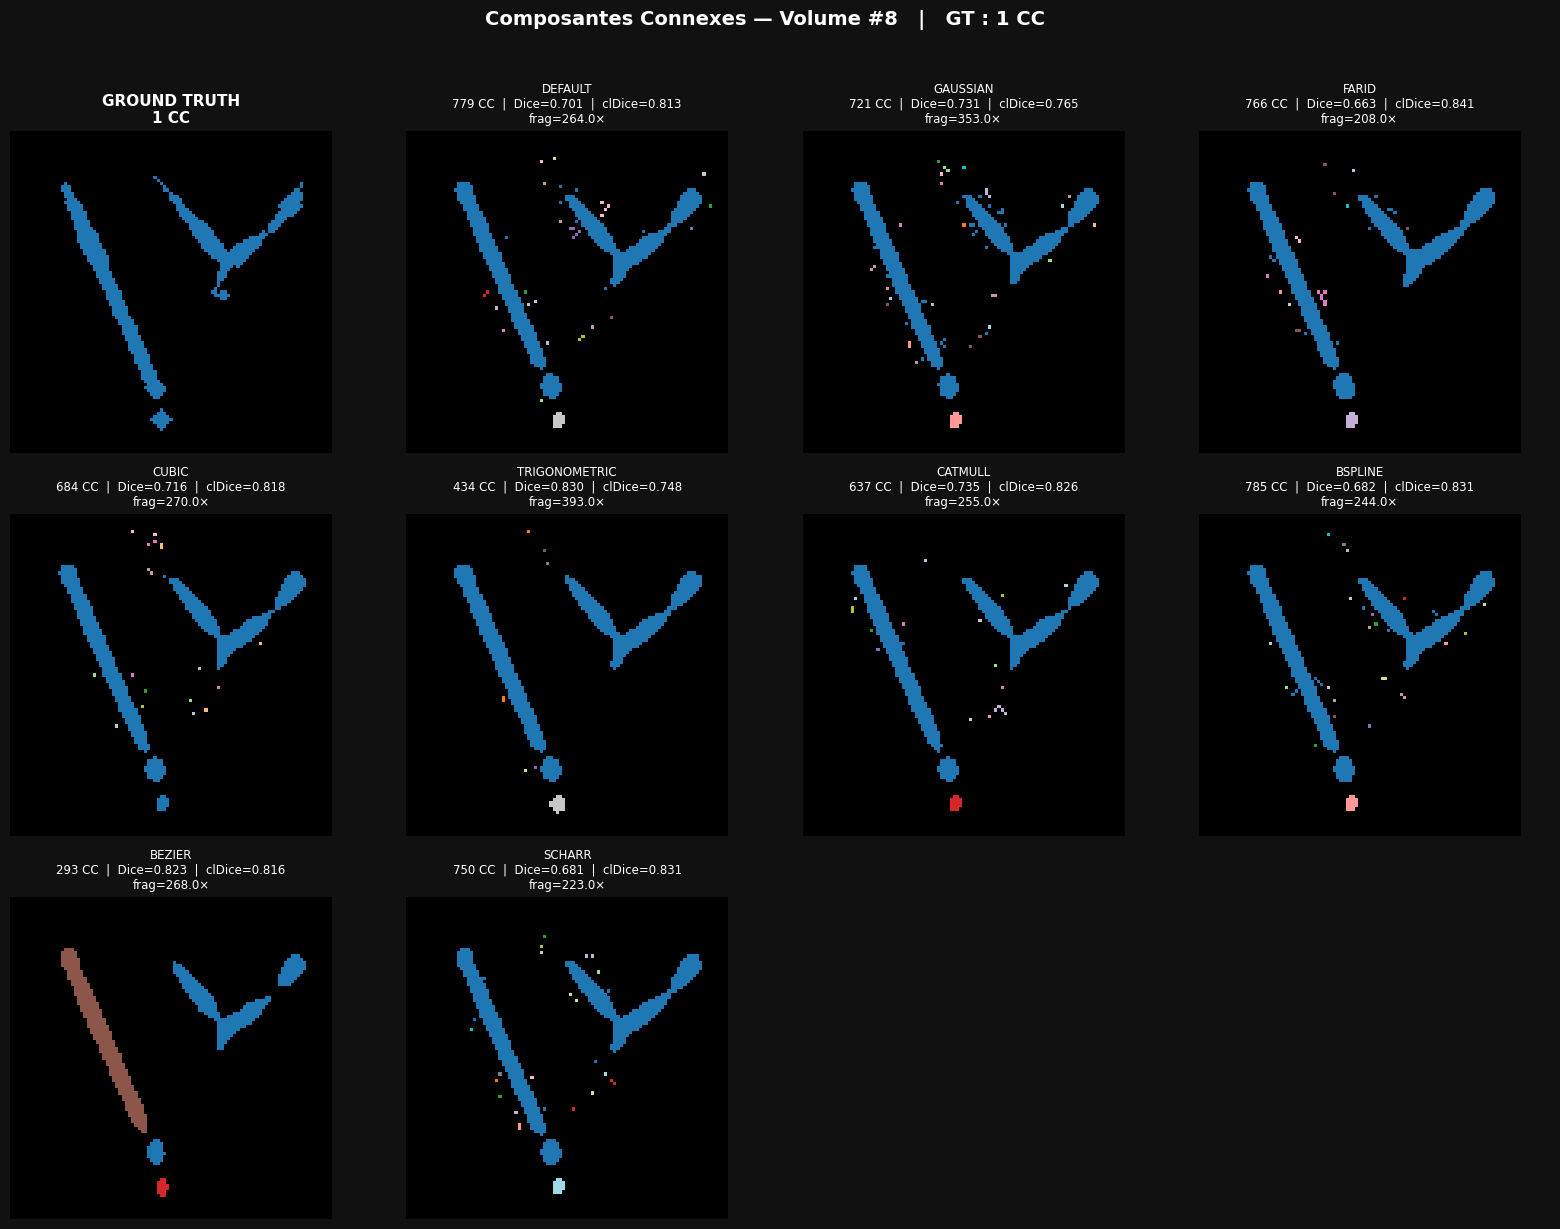

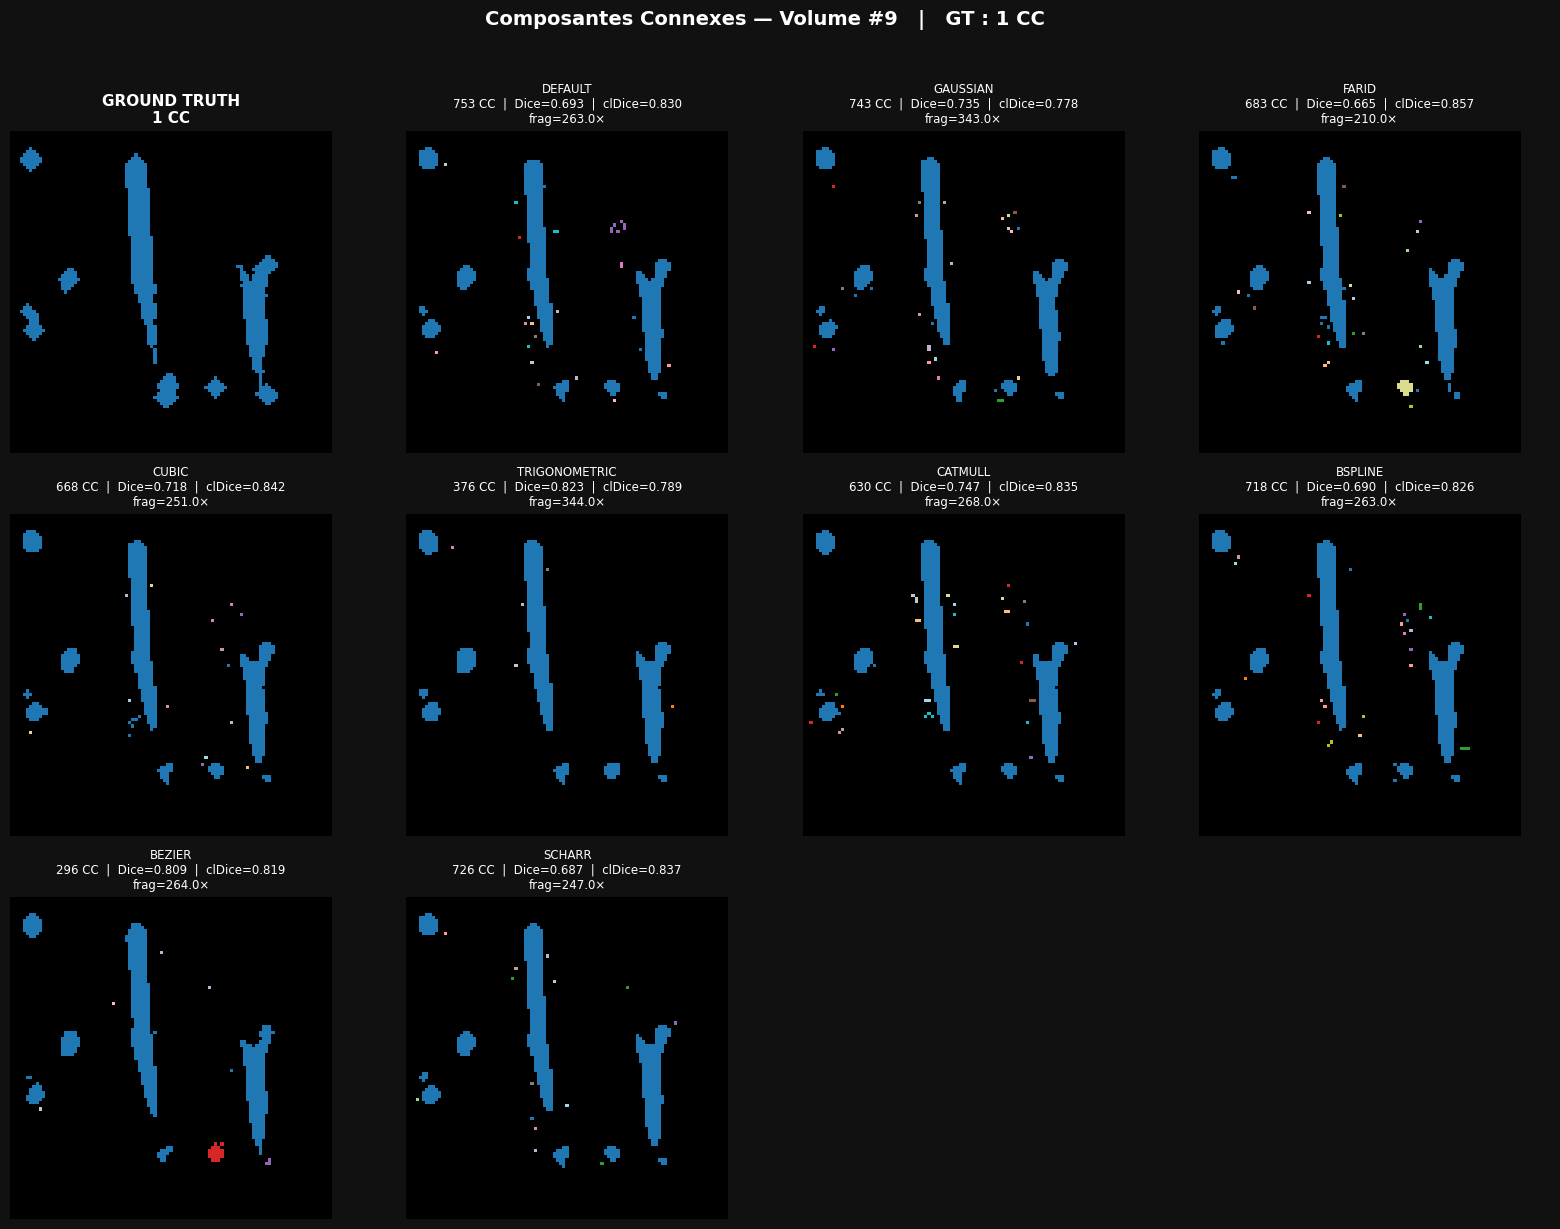

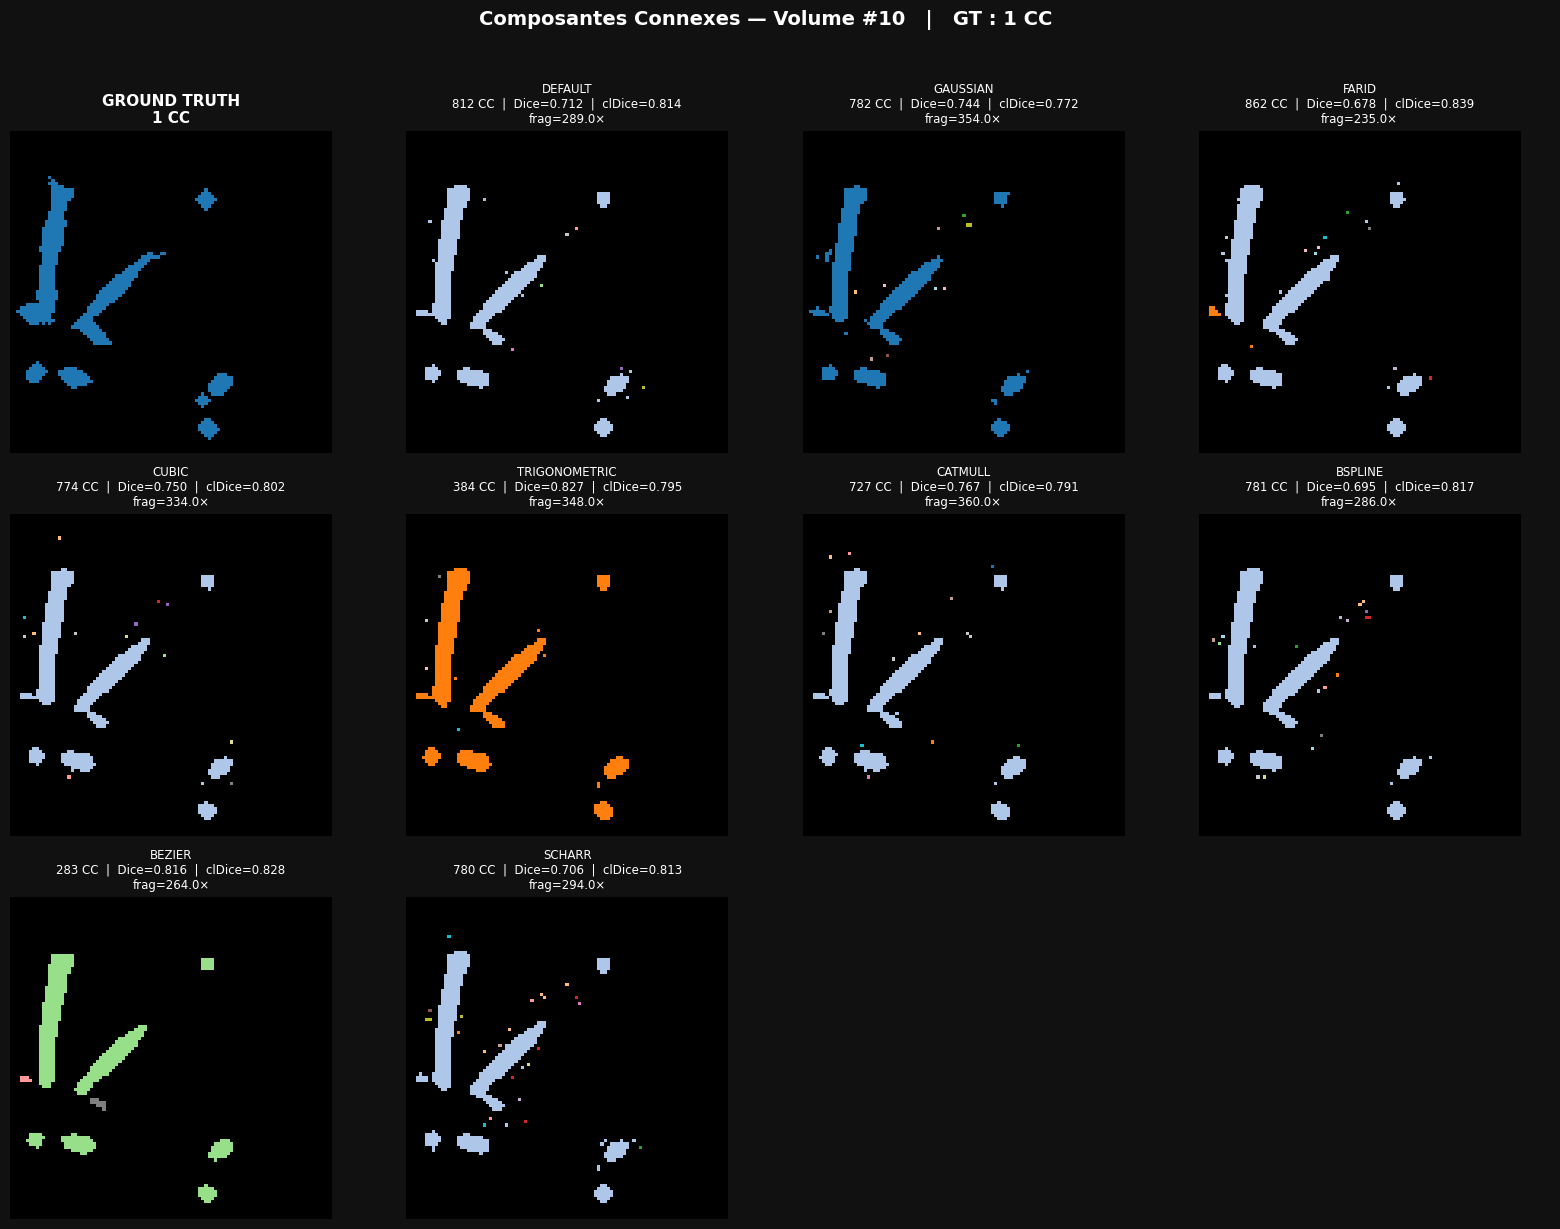

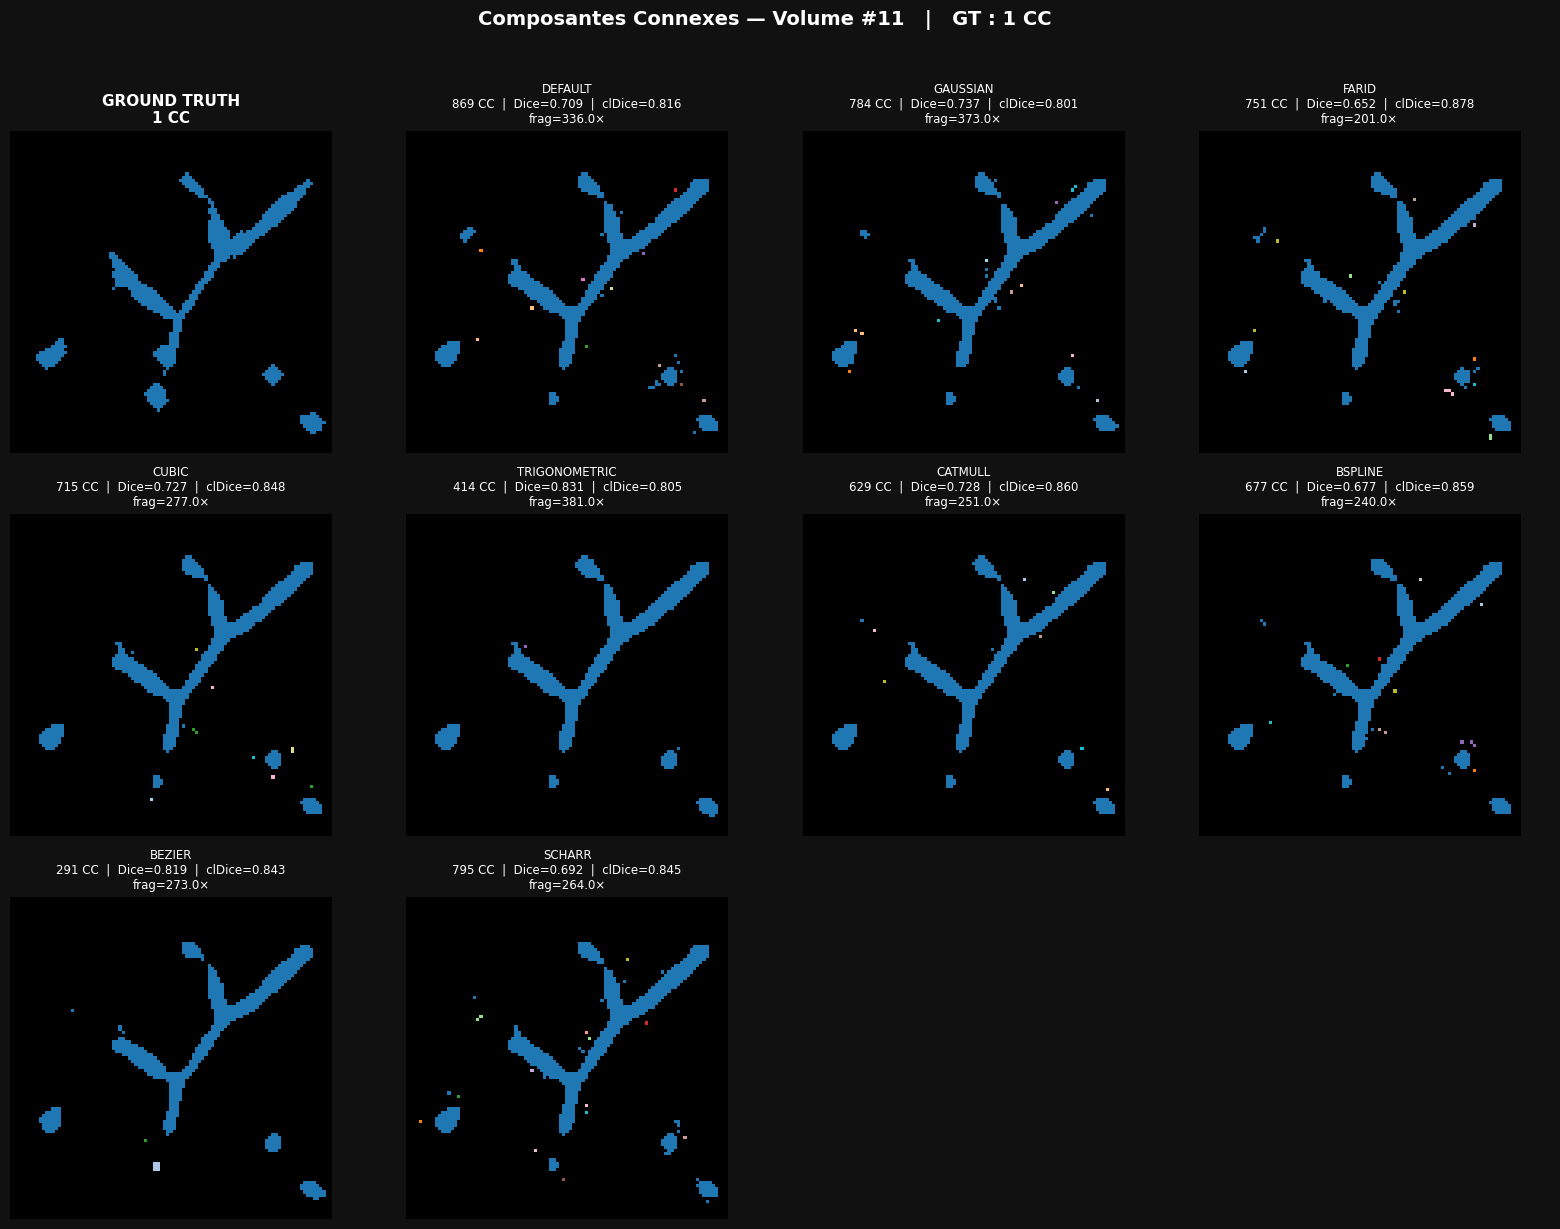

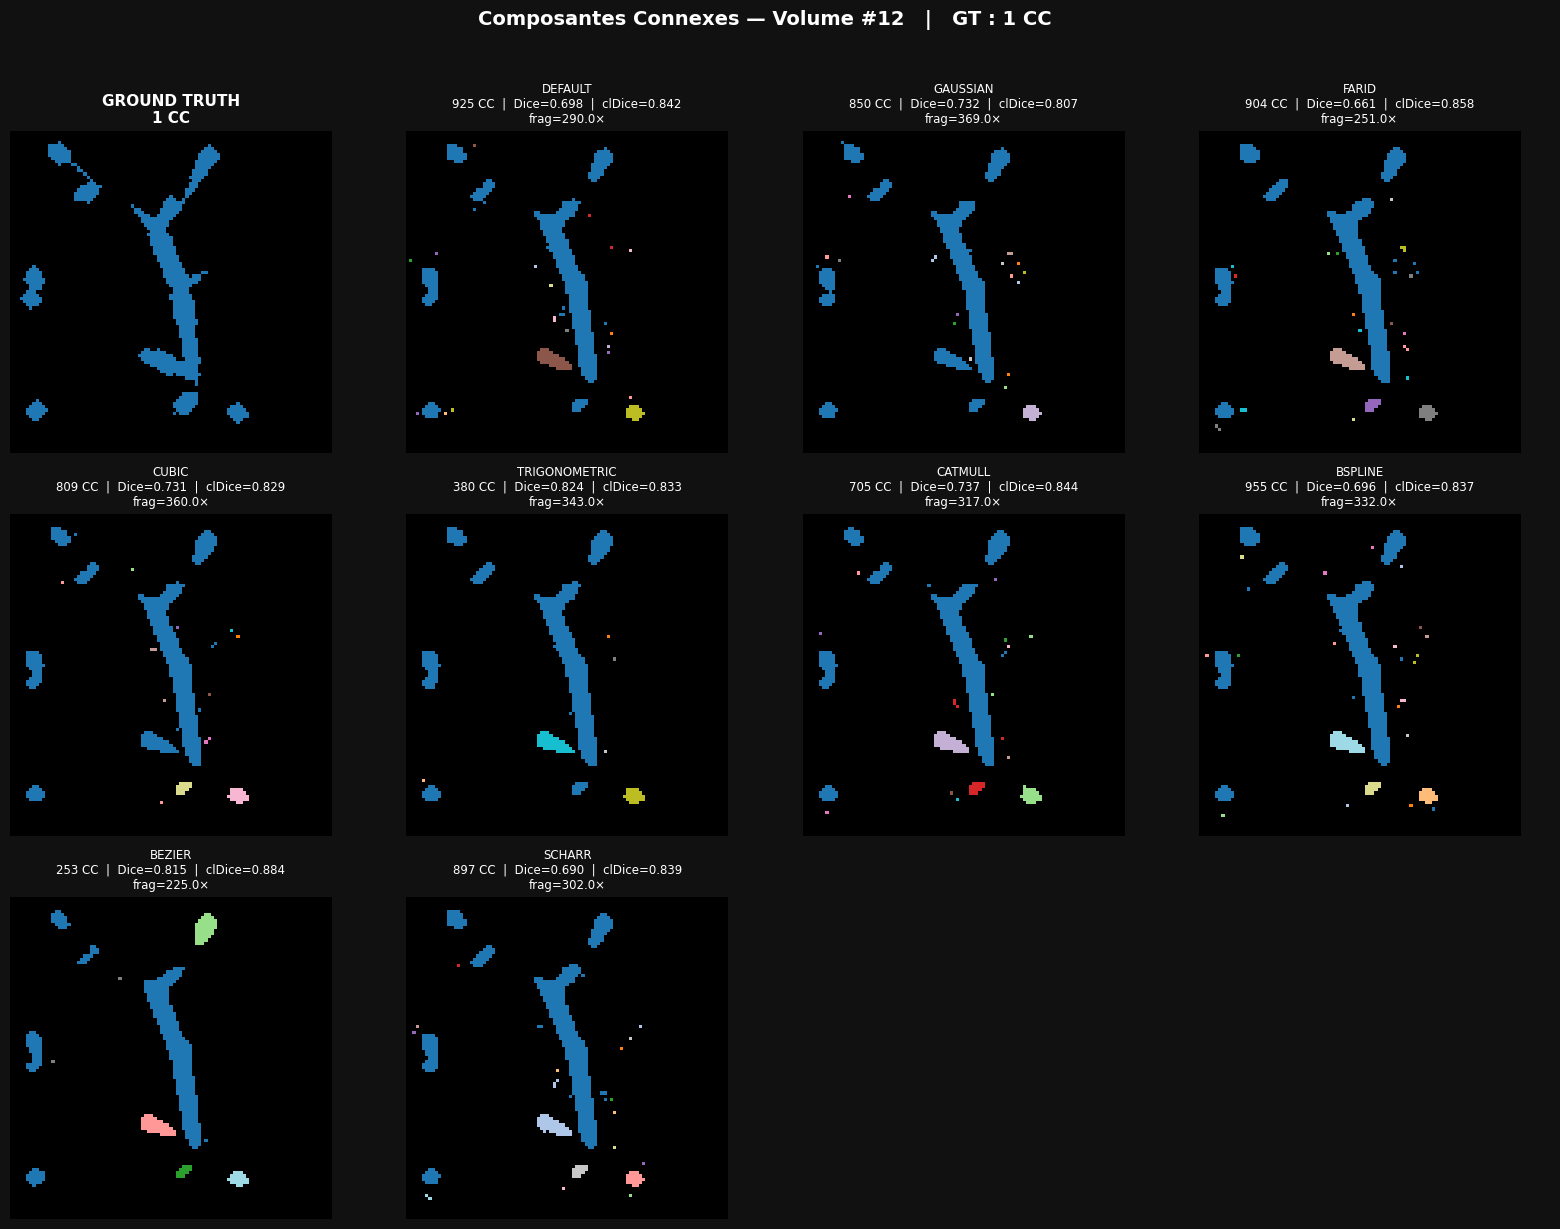

In [17]:
# ─── Grille CC pour tous les volumes ──────────────────────────────────────────
# Une figure par volume (12 figures au total), 3 × 4 sous-graphes

AXIS = 'z'

# Utiliser tous les opérateurs
DISPLAY_METHODS = METHODS  # Inclut 'scharr'

for vol_idx in range(1, 13):
    gt_mask = SAVED_GT[METHODS[0]][vol_idx - 1]
    if gt_mask is None:
        print(f"[Vol #{vol_idx}] données manquantes, ignoré")
        continue

    z_best = int(np.argmax(gt_mask.sum(axis=(0, 1))))
    
    gt_labeled, n_gt, gt_cmap = colorize_cc(gt_mask)
    gt_slice = get_slice(gt_labeled, AXIS, position=z_best)
    gt_rgb = make_cc_rgb(gt_slice, gt_cmap, n_gt)

    # Grille 3×4 = 12 cellules
    n_cols = 4
    n_rows = 3
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12),
                             facecolor='#111111')
    axes_flat = axes.flatten()

    fig.suptitle(
        f"Composantes Connexes — Volume #{vol_idx}   |   GT : {n_gt} CC",
        color='white', fontsize=14, fontweight='bold', y=1.02
    )

    # ── Cellule 0 : Ground Truth ─────────────────────────────────────────────
    ax = axes_flat[0]
    ax.set_facecolor('#111111')
    ax.imshow(gt_rgb, interpolation='none', origin='lower')
    ax.set_title(f"GROUND TRUTH\n{n_gt} CC",
                 color='white', fontsize=11, fontweight='bold')
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor('#00FF88')
        spine.set_linewidth(3)
        spine.set_visible(True)

    # ── Cellules 1-9 : opérateurs (jusqu'à 9 opérateurs) ──────────────────────
    for i, method in enumerate(DISPLAY_METHODS, 1):
        if i >= len(axes_flat):
            break
            
        ax = axes_flat[i]
        ax.set_facecolor('#111111')

        pred_mask = SAVED_BINARY[method][vol_idx - 1]
        if pred_mask is None:
            ax.text(0.5, 0.5, 'ERREUR', transform=ax.transAxes,
                    ha='center', va='center', color='red', fontsize=12)
            ax.axis('off')
            continue

        pred_labeled, n_pred, pred_cmap = colorize_cc(pred_mask)
        pred_slice = get_slice(pred_labeled, AXIS, position=z_best)
        pred_rgb = make_cc_rgb(pred_slice, pred_cmap, n_pred)

        m_list = RAW_METRICS[method]
        m = m_list[vol_idx - 1] if m_list[vol_idx - 1] is not None else {}
        dice_v = m.get('dice', np.nan)
        cld_v = m.get('cldice', np.nan)
        frag_v = m.get('fragmentation_ratio', np.nan)

        ax.imshow(pred_rgb, interpolation='none', origin='lower')
        ax.set_title(
            f"{method.upper()}\n"
            f"{n_pred} CC  |  Dice={dice_v:.3f}  |  clDice={cld_v:.3f}\n"
            f"frag={frag_v:.1f}×",
            color='white', fontsize=8.5
        )
        ax.axis('off')

        border_color = '#00C875' if dice_v >= 0.79 else '#FFC107' if dice_v >= 0.73 else '#FF5252'
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(3)
            spine.set_color(border_color)

    # Cacher les cellules vides
    for j in range(len(DISPLAY_METHODS) + 1, len(axes_flat)):
        axes_flat[j].axis('off')
        axes_flat[j].set_facecolor('#111111')

    plt.tight_layout()
    plt.show()
    plt.close(fig)

In [18]:
def colorize_cc(mask: np.ndarray):
    """
    Retourne un array labelisé, le nombre de composantes et la colormap.
    """
    struct = np.ones((3, 3, 3))
    labeled, n_cc = scipy_label(mask.astype(bool), structure=struct)
    # Palette cyclique tab20
    cmap = plt.get_cmap('tab20', 20)  # 20 couleurs fixes
    return labeled, n_cc, cmap


def make_cc_rgb(slice_2d, cmap, n_cc):
    """Convertit un slice labelisé en image RGB avec fond noir.
    Chaque composante reçoit une couleur UNIQUE et DISTINCTE."""
    h, w = slice_2d.shape
    rgb = np.zeros((h, w, 3))
    
    # Pré-générer les couleurs pour chaque composante
    # Utiliser tab20 cycliquement pour avoir des couleurs bien distinctes
    colors = []
    for i in range(n_cc):
        # Prendre une couleur de tab20 (cycle toutes les 20)
        idx = i % 20
        color = cmap(idx)[:3]  # (R,G,B)
        colors.append(color)
    
    # Colorier chaque pixel selon sa composante
    for lbl in range(1, n_cc + 1):
        mask = slice_2d == lbl
        if mask.any():
            rgb[mask] = colors[lbl - 1]
    
    return rgb


def get_slice(labeled, axis='z', position=None):
    """Coupe 2D d'un volume 3D labelisé."""
    if position is None:
        # Par défaut, prend la coupe médiane
        shape = labeled.shape
        if axis == 'x':
            position = shape[0] // 2
        elif axis == 'y':
            position = shape[1] // 2
        else:
            position = shape[2] // 2
    
    if axis == 'x':
        return labeled[position, :, :].T
    if axis == 'y':
        return labeled[:, position, :].T
    return labeled[:, :, position].T

In [19]:
from scipy.ndimage import label as scipy_label
from core.experiments.metrics import detailed_metrics  # ou votre import habituel


def filter_by_component_size(binary_mask: np.ndarray, min_size: int):
    """
    Supprime les composantes connexes dont la taille (en voxels) est < min_size.

    Retourne :
        filtered  : masque binaire filtré (bool ndarray)
        n_removed : nombre de composantes supprimées
        sizes     : liste des tailles de toutes les composantes avant filtrage
    """
    struct = np.ones((3, 3, 3), dtype=bool)
    labeled, n_cc = scipy_label(binary_mask.astype(bool), structure=struct)

    if n_cc == 0:
        return np.zeros_like(binary_mask, dtype=bool), 0, []

    # Taille de chaque composante (label 0 = fond, ignoré)
    sizes = np.bincount(labeled.ravel())[1:]   # shape (n_cc,)

    # Labels à conserver
    keep_labels = np.where(sizes >= min_size)[0] + 1   # +1 car bincount[0] = fond
    n_removed   = n_cc - len(keep_labels)

    filtered = np.isin(labeled, keep_labels)
    return filtered, n_removed, sizes.tolist()


def optimize_size_filtering(
    vol_idx: int,
    operators: list,
    min_sizes: list = None,
    metric: str = "cldice",        # "cldice" | "dice" | "f1"
):
    """
    Pour un volume donné, teste plusieurs valeurs de min_size de filtrage par CC
    et retourne, pour chaque opérateur, la taille minimale qui maximise `metric`.

    Paramètres
    ----------
    vol_idx   : index du volume (1-12)
    operators : liste des noms d'opérateurs (ex. METHODS)
    min_sizes : liste de tailles à tester (défaut : [2, 5, 10, 20, 30, 40, 50])
    metric    : métrique à maximiser — "cldice", "dice", ou "f1" (= dice)

    Retourne
    --------
    results : dict[method] = {
        "baseline_dice"     : float,      # Dice sans filtrage
        "baseline_cldice"   : float,      # clDice sans filtrage
        "best_min_size"     : int,
        "best_dice"         : float,
        "best_cldice"       : float,
        "best_gain"         : float,      # gain sur la métrique pilote vs baseline
        "best_n_components" : int,        # nb CC après filtrage optimal
        "all_results"       : list[dict], # une entrée par min_size testé
    }
    """
    if min_sizes is None:
        min_sizes = [2, 5, 10, 20, 30, 40, 50]

    lbl = load_label(LABELS_DIR, vol_idx)          # (101,101,101) uint8
    gt_bin = lbl.astype(bool)

    results = {}

    for method in operators:
        pred_mask = SAVED_BINARY[method][vol_idx - 1]
        enh_map   = SAVED_ENHANCED[method][vol_idx - 1]

        if pred_mask is None or enh_map is None:
            results[method] = None
            continue

        # ── Baseline (sans filtrage) ──────────────────────────────────────
        m_base = detailed_metrics(
            y_pred=enh_map,
            y_true=gt_bin.astype(np.float32),
            threshold=float(enh_map[pred_mask].min()) if pred_mask.any() else 0.5,
        )
        baseline_dice   = m_base.get("dice",   np.nan)
        baseline_cldice = m_base.get("cldice", np.nan)
        baseline_score  = m_base.get(metric,   baseline_dice)

        # ── Sweep min_size ────────────────────────────────────────────────
        all_results = []
        best_min_size    = 0
        best_score       = baseline_score
        best_dice        = baseline_dice
        best_cldice      = baseline_cldice
        best_n_components = int(scipy_label(pred_mask)[1])

        for min_size in min_sizes:
            filtered, n_removed, _ = filter_by_component_size(pred_mask, min_size)

            if not filtered.any():
                # Filtrage trop agressif — tout a disparu
                all_results.append({
                    "min_size"     : min_size,
                    "dice"         : 0.0,
                    "cldice"       : 0.0,
                    "n_components" : 0,
                    "n_removed"    : n_removed,
                })
                continue

            # Recalcul des métriques sur le masque filtré
            # On reconstruit un pseudo-score continu binaire pour detailed_metrics
            pseudo_pred = filtered.astype(np.float32)
            m = detailed_metrics(
                y_pred=pseudo_pred,
                y_true=gt_bin.astype(np.float32),
                threshold=0.5,
            )

            d   = m.get("dice",   np.nan)
            cld = m.get("cldice", np.nan)
            sc  = m.get(metric,   d)

            _, n_cc_after = scipy_label(filtered)

            all_results.append({
                "min_size"     : min_size,
                "dice"         : d,
                "cldice"       : cld,
                "n_components" : n_cc_after,
                "n_removed"    : n_removed,
            })

            if sc > best_score:
                best_score        = sc
                best_min_size     = min_size
                best_dice         = d
                best_cldice       = cld
                best_n_components = n_cc_after

        results[method] = {
            "baseline_dice"     : baseline_dice,
            "baseline_cldice"   : baseline_cldice,
            "best_min_size"     : best_min_size,
            "best_dice"         : best_dice,
            "best_cldice"       : best_cldice,
            "best_gain"         : best_score - baseline_score,
            "best_n_components" : best_n_components,
            "all_results"       : all_results,
        }

    return results

In [20]:
# ==========================================================
# VISUALISATION DES MASQUES FILTRÉS - CORRIGÉ
# ==========================================================
def visualize_filtering_effect_all_methods(
    vol_idx=3,
    methods=None,
    min_sizes=(10, 20, 30, 40, 50)
):
    """
    Affiche l'effet du filtrage par taille minimale
    pour tous les opérateurs.
    """

    from scipy.ndimage import label
    import numpy as np
    import matplotlib.pyplot as plt

    if methods is None:
        methods = METHODS

    img = load_mhd(IMAGES_DIR, vol_idx)
    lbl = load_label(LABELS_DIR, vol_idx)

    z_best = int(np.argmax(lbl.sum(axis=(0, 1))))

    n_rows = len(methods)
    n_cols = len(min_sizes) + 2

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4*n_cols, 3.8*n_rows),
        squeeze=False
    )

    fig.suptitle(
        f"Effet du filtrage par taille — volume {vol_idx}",
        fontsize=15,
        fontweight='bold',
        y=1.02
    )

    # Titres colonnes
    column_titles = (
        ["Originale", "Brute"] +
        [f"min={m}" for m in min_sizes]
    )

    for col in range(n_cols):
        axes[0, col].set_title(
            column_titles[col],
            fontsize=12,
            fontweight='bold'
        )

    for row, method in enumerate(methods):

        try:
            enh, seg, thr, lbl_vol, br, hessian_time = run_pipeline(
                vol_idx,
                processing_cfg,
                hessian_cfg,
                seg_cfg,
                method
            )

        except Exception as e:
            print(f"Erreur {method}: {e}")
            continue

        # --------------------------------------------
        # Label visible à gauche
        # --------------------------------------------
        fig.text(
            0.02,
            1 - ((row + 0.5) / n_rows),
            method.upper(),
            fontsize=13,
            fontweight='bold',
            va='center',
            ha='left',
            bbox=dict(
                facecolor='white',
                edgecolor='black',
                alpha=0.9,
                pad=4
            )
        )

        # --------------------------------------------
        # Originale
        # --------------------------------------------
        axes[row, 0].imshow(
            img[:, :, z_best],
            cmap='gray'
        )

        axes[row, 0].set_title(
            f"{method.upper()}\nOriginale",
            fontsize=11,
            fontweight='bold'
        )

        axes[row, 0].axis("off")

        # --------------------------------------------
        # Brute
        # --------------------------------------------
        labeled_init, n_init = label(seg)

        axes[row, 1].imshow(
            seg[:, :, z_best],
            cmap='gray'
        )

        axes[row, 1].text(
            0.03,
            0.95,
            f"{n_init} CC",
            transform=axes[row, 1].transAxes,
            color='yellow',
            fontsize=8,
            verticalalignment='top',
            bbox=dict(facecolor='black', alpha=0.6)
        )

        axes[row, 1].axis("off")

        # --------------------------------------------
        # filtrages successifs
        # --------------------------------------------
        for i, min_size in enumerate(min_sizes):

            filtered_seg, n_removed, _ = filter_by_component_size(
                seg,
                min_size
            )

            labeled_final, n_final = label(filtered_seg)

            axes[row, i + 2].imshow(
                filtered_seg[:, :, z_best],
                cmap='tab20',
                interpolation='none'
            )

            axes[row, i + 2].text(
                0.03,
                0.95,
                f"{n_final} CC\n-{n_removed}",
                transform=axes[row, i + 2].transAxes,
                fontsize=8,
                color='white',
                verticalalignment='top',
                bbox=dict(facecolor='black', alpha=0.6)
            )

            axes[row, i + 2].axis("off")

    plt.tight_layout(rect=[0.06, 0, 1, 0.97])
    plt.show()

    return fig